# E76 · Metamers: one colour, many spectra

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) **reflectance spectra of the 1,269 chips of the Munsell Book of Color** (matte finish), measured with a spectrophotometer at 1 nm from 380 to 800 nm (University of Kuopio / University of Eastern Finland spectral database, Hauta-Kasari; Zenodo mirror); (2) the **CIE 1964 observer** and four **CIE lights**: daylight D65, incandescent A (computed from Planck's law), the narrow-band fluorescent FL11 and a warm-white LED, LED-B2 |
| **You will learn** | The observer as a **3 x 41 linear map**, its **38-dimensional null space**, and building metamers by hand ("metameric blacks") · the **metamer-mismatch body**: every colour physics allows under a second light, by **linear programming** · why integrating an illuminant properly matters (fluorescent lines) · three **priors for spectra** on the logit scale - a smoothness-only GP, a covariance **learned from real surfaces**, and the classic 3-component linear model - compared by held-out density and by what they imply · **inverting colour to spectrum in PyMC**, batched over chips · validation on **held-out chips with known spectra**: coverage of spectral bands and **calibration of the predicted colour under other lights** (interval coverage, PIT, a ΔE00-based PIT) · a failure and its fix: the 3-component model is **confidently wrong**; the learned prior is calibrated · **one light or two**: how much a second measurement shrinks the metamer set · a **decision**: choosing a chip or a paint recipe for a gallery lit by daylight and LED - expected loss over the posterior and the lighting vs naive rules, the value of a second measurement, and why a calibrated posterior can still lose to a rule that uses local structure · **uncertainty displays where colour is the uncertainty**: spaghetti of spectra in their rendered colours, swatch fans, mismatch clouds against the physical limit, split swatches, and an animation through the metamers |

## The setting

Two paint samples match perfectly in the shop. At home, under the kitchen's warm LEDs, one is
visibly pinker than the other. Nothing is wrong with the paints or with your eyes: they are
**metamers**, surfaces with different reflectance spectra that happen to produce the same three
cone responses under one light, and not under another.

It follows from counting. A reflectance spectrum is a curve: here 41 numbers, one every 10 nm from
380 to 780 nm. A colour measurement (a colorimeter's CIELAB, or the eye's three cone signals) is 3
numbers. So "which spectrum has this colour?" has a 38-dimensional family of answers, and the colour
of the same surface under a **different** light depends on where in that family the surface is.

That makes it a natural Bayesian problem:

* the **likelihood** says which spectra reproduce the measured colour (and it is flat along 38
  directions);
* the **prior** says which spectra real surfaces have - and does almost all the work;
* the **posterior** is the set of plausible metamers, and its most useful summary is a
  **prediction**: the colour under the gallery's LEDs, with honest uncertainty.

We learn the prior from real measured surfaces (the Munsell chips), invert colours of chips that were
held out, and check the predictions against their measured spectra.

| part | question | tool |
|---|---|---|
| A | What are the data, and how does a spectrum become a colour? | CIE observer, illuminants, CIELAB, CIEDE2000 |
| B | What can the observer not see? | null space, metameric blacks, metamer-mismatch bodies by linear programming |
| C | Which spectra are plausible? | three priors on logit-reflectance; held-out density; a closed-form preview |
| D | What does one colour say about the spectrum? | batched inversion in PyMC; spaghetti, swatch fans, mismatch clouds |
| E | Is the posterior honest? | coverage and PIT on held-out chips; where it is confident |
| F | One light or two? | a second measurement under incandescent light |
| G | Which paint recipe should we use? | expected ΔE00 under uncertain gallery lighting; value of information |
| H | An animation | walking through the metamers, physically possible vs plausible |

In [1]:
import io
import logging
import time
import warnings
from itertools import combinations

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML, Image, display
from matplotlib import animation
from matplotlib.patches import Ellipse, Patch
from scipy.optimize import linprog, minimize
from scipy.spatial import ConvexHull
from scipy.stats import beta as beta_dist

from pymc_challenges import data

RANDOM_SEED = 76
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)


def show_jpeg(fig, quality=85):
    """Swatch-heavy and many-coloured figures are far smaller as JPEG than PNG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=90, pil_kwargs={"quality": quality})
    plt.close(fig)
    display(Image(buf.getvalue()))

## A. The data, and how a spectrum becomes a colour

The **Munsell Book of Color** is a physical atlas of painted chips arranged by *hue* (10 families,
R, YR, Y, ..., RP, each at 2.5, 5, 7.5 and 10), *value* (lightness, 2.5 to 9) and *chroma*
(colourfulness, 1 to 14). The University of Kuopio measured the reflectance spectrum of every chip
of the matte edition, 1,269 of them: the fraction of light reflected at each wavelength. Our file
keeps 10 nm steps (each value the mean of the 1 nm readings within ±4 nm).

The Zenodo record that mirrors the database gives its licence as "not specified". This repository
keeps a derived 10 nm copy for teaching, with attribution to the database; anyone redistributing it
further should check the terms with the database's owners.

In [2]:
data.describe("munsell_matt")
mun = data.load("munsell_matt")
data.describe("cie_illuminants_e76")
ill = data.load("cie_illuminants_e76").set_index("wavelength")
cie = data.load("cie1964_d65").set_index("wavelength")

WL = np.arange(380, 781, 10)                      # 41 wavelengths
R_ALL = mun[[f"r{w}" for w in WL]].to_numpy()
print(mun[["chip", "hue_family", "value", "chroma"]].sample(4, random_state=1).to_string(index=False))
print(f"{len(mun)} chips x {len(WL)} wavelengths; reflectance {R_ALL.min():.3f} to {R_ALL.max():.3f}")

munsell_matt: Reflectance spectra of the 1,269 chips of the Munsell Book of Color, Matte Finish Collection (1976), measured on a Perkin-Elmer Lambda 9 at 1 nm. One row per chip: chip (e.g. '2.5R 9/2'), hue, hue_family (R, YR, Y, GY, G, BG, B, PB, P, RP), value, chroma, r380 ... r780 (reflectance 0-1 at 10 nm, the mean of the 1 nm readings within +-4 nm).
  source: Munsell Colors Matt (spectrophotometer measured), University of Kuopio / University of Eastern Finland spectral color research database (Hauta-Kasari, n.d.; measured by J. Hiltunen), mirrored on Zenodo 3269912 by the colour-science project. Licence field on Zenodo: 'not specified'; cite the database. BUILT by tools/build_e76_metamers.py (10 nm means of the 1 nm data) - keep the cached file.
  url:    https://zenodo.org/records/3269912
cie_illuminants_e76: wavelength (380-780 nm, 5 nm) and relative spectral power of A (incandescent, 2856 K), FL2 (cool-white fluorescent), FL11 (narrow-band triphosphor fluorescent), LED_B2 and L

### The observer, the light and CIELAB

As in E74: the tristimulus values of a surface with reflectance $R(\lambda)$ under a light with power
$S(\lambda)$ are sums of $R\,S\,\bar x$ (and $\bar y$, $\bar z$) over wavelength, with the CIE 1964
colour-matching functions, normalised so that a perfect white gives $X = Y = Z = 1$. CIELAB is then
a fixed cube-root transform. Normalising by the white *of the light in use* is CIELAB's built-in
(and crude) model of **adaptation**: a viewer who has adjusted to warm light sees a white wall as
white. So "the colour under A" below means the colour a viewer adapted to A sees, and a swatch
"rendered under A" is that colour shown on your (daylight-white) screen.

**One detail matters here.** The reflectances are known at 10 nm steps, but the lights are not smooth:
the fluorescent FL11 concentrates its power in narrow mercury and phosphor lines. Sampling the
light at the same 10 nm points throws most of a line away or doubles it. The right weights
integrate the fine (1 nm) light x colour-matching functions against the linear interpolation of $R$
between the 10 nm nodes (a "hat" function per node) - the idea behind the ASTM E308 weighting
tables. The table below compares the two for all 1,269 chips.

In [3]:
L1 = np.arange(380, 781)                                      # 1 nm grid
CMF = cie.loc[L1, ["xbar", "ybar", "zbar"]].to_numpy()
HAT = np.maximum(0, 1 - np.abs(L1[:, None] - WL[None]) / 10)  # 1 nm x node: linear interpolation
LIGHT_NAMES = {"D65": "daylight (D65)", "A": "incandescent (A)", "FL11": "fluorescent (FL11)",
               "LED_B2": "warm LED (LED-B2)"}
LIGHTS = list(LIGHT_NAMES)


def light_spd(name):
    """Relative power on the 1 nm grid (5 nm tables interpolated linearly)."""
    if name == "D65":
        return cie.loc[L1, "d65"].to_numpy()
    return np.interp(L1, ill.index, ill[name])


def observer(s):
    """41 x 3 weights: reflectance at the 10 nm nodes @ W -> XYZ relative to the light's white."""
    Wm = HAT.T @ (s[:, None] * CMF)
    return Wm / Wm.sum(0)


W = {k: observer(light_spd(k)) for k in LIGHTS}
D65_WHITE_2DEG = np.array([0.95047, 1.0, 1.08883])
M_SRGB = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]])


def xyz_to_lab(XYZ):
    d = 6 / 29
    f = np.where(XYZ > d**3, np.cbrt(np.maximum(XYZ, 1e-12)), XYZ / (3 * d**2) + 4 / 29)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)


def lab(R, light="D65"):
    """CIELAB of reflectance(s) R under a light (a name, or a 41 x 3 weight matrix)."""
    Wm = W[light] if isinstance(light, str) else light
    return xyz_to_lab(R @ Wm)


def lab_pt(R, Wm):
    """The same observer + CIELAB inside a PyTensor graph."""
    d = 6 / 29
    XYZ = pt.dot(R, Wm)
    f = pt.switch(XYZ > d**3, pt.maximum(XYZ, 1e-6) ** (1 / 3), XYZ / (3 * d**2) + 4 / 29)
    return pt.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)


def lab_to_srgb(lab):
    d = 6 / 29
    fy = (lab[..., 0] + 16) / 116
    f = np.stack([fy + lab[..., 1] / 500, fy, fy - lab[..., 2] / 200], -1)
    XYZ = np.where(f > d, f**3, 3 * d**2 * (f - 4 / 29)) * D65_WHITE_2DEG
    lin = np.clip(XYZ @ np.linalg.inv(M_SRGB).T, 0, 1)
    return np.where(lin <= 0.0031308, 12.92 * lin, 1.055 * lin ** (1 / 2.4) - 0.055)


def rgb(R, light="D65"):
    """The colour a surface shows to a viewer adapted to the light, as an sRGB triple."""
    return lab_to_srgb(lab(R, light))


def de2000(lab1, lab2):
    """CIEDE2000 colour difference (Sharma, Wu & Dalal 2005), vectorised over leading axes."""
    L1_, a1, b1 = np.moveaxis(np.asarray(lab1, float), -1, 0)
    L2, a2, b2 = np.moveaxis(np.asarray(lab2, float), -1, 0)
    Cb = (np.hypot(a1, b1) + np.hypot(a2, b2)) / 2
    G = 0.5 * (1 - np.sqrt(Cb**7 / (Cb**7 + 25.0**7)))
    a1p, a2p = (1 + G) * a1, (1 + G) * a2
    C1p, C2p = np.hypot(a1p, b1), np.hypot(a2p, b2)
    h1p, h2p = np.degrees(np.arctan2(b1, a1p)) % 360, np.degrees(np.arctan2(b2, a2p)) % 360
    zero = C1p * C2p == 0
    dh = h2p - h1p
    dh = np.where(dh > 180, dh - 360, np.where(dh < -180, dh + 360, dh))
    dh = np.where(zero, 0, dh)
    dL, dC = L2 - L1_, C2p - C1p
    dH = 2 * np.sqrt(C1p * C2p) * np.sin(np.radians(dh / 2))
    Lb, Cbp = (L1_ + L2) / 2, (C1p + C2p) / 2
    hs = h1p + h2p
    hb = np.where(zero, hs, np.where(np.abs(h1p - h2p) <= 180, hs / 2, np.where(hs < 360, (hs + 360) / 2, (hs - 360) / 2)))
    T = (1 - 0.17 * np.cos(np.radians(hb - 30)) + 0.24 * np.cos(np.radians(2 * hb))
         + 0.32 * np.cos(np.radians(3 * hb + 6)) - 0.20 * np.cos(np.radians(4 * hb - 63)))
    Rt = (-np.sin(np.radians(60 * np.exp(-(((hb - 275) / 25) ** 2))))
          * 2 * np.sqrt(Cbp**7 / (Cbp**7 + 25.0**7)))
    Sl = 1 + 0.015 * (Lb - 50) ** 2 / np.sqrt(20 + (Lb - 50) ** 2)
    Sc, Sh = 1 + 0.045 * Cbp, 1 + 0.015 * Cbp * T
    return np.sqrt((dL / Sl) ** 2 + (dC / Sc) ** 2 + (dH / Sh) ** 2 + Rt * (dC / Sc) * (dH / Sh))


assert abs(de2000([50, 2.6772, -79.7751], [50, 0, -82.7485]) - 2.0425) < 1e-4    # Sharma's first pair

LAB = {k: lab(R_ALL, k) for k in LIGHTS}
point = {}
for k in LIGHTS:
    Wp = light_spd(k)[WL - 380, None] * CMF[WL - 380]
    d = de2000(xyz_to_lab(R_ALL @ (Wp / Wp.sum(0))), LAB[k])
    point[k] = (np.median(d), d.max())
print("ΔE00 between point-sampled and properly integrated weights, over all chips:")
print(pd.DataFrame(point, index=["median", "max"]).round(2))
print("\nMunsell value vs L* under D65 (a check of the whole chain):")
print(pd.DataFrame({"value": mun.value, "L*": LAB["D65"][:, 0]}).groupby("value")["L*"].agg(["mean", "std"]).round(1).T)

ΔE00 between point-sampled and properly integrated weights, over all chips:
         D65     A  FL11  LED_B2
median  0.06  0.05  1.02    0.05
max     0.14  0.13  3.12    0.17

Munsell value vs L* under D65 (a check of the whole chain):
value   2.5   3.0   4.0   5.0   6.0   7.0   8.0   8.5   9.0
mean   26.4  30.5  39.5  48.8  57.8  67.0  76.2  80.3  85.9
std     0.6   0.6   0.6   0.8   0.7   0.8   0.9   0.9   0.9


For the smooth lights (daylight, incandescent, the LED) the shortcut would be harmless (0.2 ΔE00 at
most). For FL11 it is off by 1 ΔE00 for a typical chip and 3 at worst - as large as the metamerism
we are about to study. And the whole chain checks out against the atlas itself: the Munsell *value*
of a chip is designed as a lightness scale, and our L* tracks it chip by chip (about 10 L* units
per value step, with a standard deviation under 1 within each step).

The four lights, some chips, and the whole set:

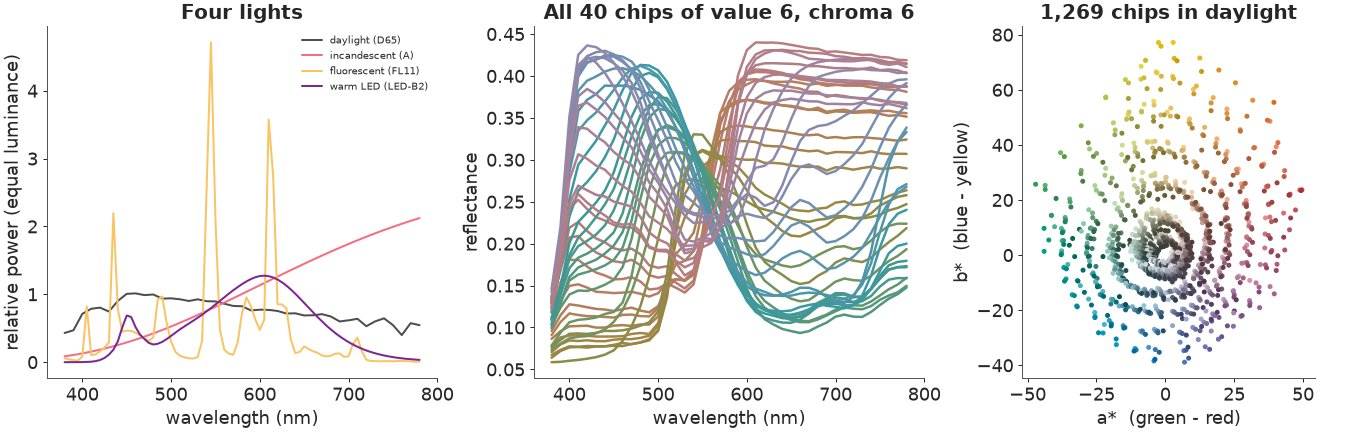

In [4]:
fig = plt.figure(figsize=(15, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.1, 1])
ax = fig.add_subplot(gs[0])
for k, c in zip(LIGHTS, ["0.3", "C1", "C2", "C3"]):
    s = light_spd(k)
    ax.plot(L1, s / (s * CMF[:, 1]).sum() * 100, color=c, lw=1.6, label=LIGHT_NAMES[k])
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("relative power (equal luminance)")
ax.legend(fontsize=8)
ax.set_title("Four lights")

ax = fig.add_subplot(gs[1])
ring = mun[(mun.value == 6) & (mun.chroma == 6)]
for i in ring.index:
    ax.plot(WL, R_ALL[i], color=rgb(R_ALL[i]), lw=2)
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("reflectance")
ax.set_title(f"All {len(ring)} chips of value 6, chroma 6")

ax = fig.add_subplot(gs[2])
ax.scatter(LAB["D65"][:, 1], LAB["D65"][:, 2], c=rgb(R_ALL), s=9)
ax.set_xlabel("a*  (green - red)")
ax.set_ylabel("b*  (blue - yellow)")
ax.set_aspect("equal")
ax.set_title("1,269 chips in daylight")
show_jpeg(fig)

Real surface spectra are smooth, broad curves: a hue is mostly *where* the curve rises or peaks,
chroma *how much* it does. Most of the chips' variety sits in a few shapes; Part C makes that
precise, and it is the whole reason colour can be inverted at all. Note also that the curves keep
changing above 700 nm, where the eye is almost blind: no colour measurement can say anything about
that part of a spectrum.

## B. What the observer cannot see

### A 3 x 41 matrix and its null space

Under one light, the observer is a linear map $A$ from 41 reflectances to 3 tristimulus values,
$\text{XYZ} = A R$ (CIELAB is a fixed function of XYZ). A 3 x 41 matrix has a **null space** of
dimension 38: any spectrum $b$ with $A b = 0$ can be added to a surface without changing its colour.
Wyszecki called such $b$ **metameric blacks**; Cohen split every spectrum into a **fundamental
metamer** (its projection onto the three-dimensional row space of $A$, which fixes the colour) and a
black (everything the observer cannot see):

$$R = \underbrace{A^\top (A A^\top)^{-1} A\, R}_{\text{fundamental}} + \underbrace{\big(I - A^\top (A A^\top)^{-1} A\big) R}_{\text{metameric black}}.$$

Swapping blacks between surfaces makes new metamers. Take one chip, keep its fundamental, and give it
the black of another chip (keeping only results that stay between 0 and 1).

In [5]:
A_obs = W["D65"].T                                           # 3 x 41: the observer as a matrix
U, S, Vt = np.linalg.svd(A_obs)
P_FUND = A_obs.T @ np.linalg.solve(A_obs @ A_obs.T, A_obs)   # projection onto what the observer sees
print("singular values of the daylight observer:", S.round(3), f"; null space: {len(WL) - 3} dimensions")

focus = int(mun.index[mun.chip == "5GY 6/6"][0])
R0 = R_ALL[focus]
fund, black = P_FUND @ R0, R0 - P_FUND @ R0
print(f"chip {mun.chip[focus]}: size of its black relative to the spectrum {np.linalg.norm(black) / np.linalg.norm(R0):.2f}; "
      f"XYZ of the black alone: {(black @ W['D65']).round(12)}")
share = np.linalg.norm(R_ALL - R_ALL @ P_FUND.T, axis=1) / np.linalg.norm(R_ALL, axis=1)
print(f"over all chips, the black is {np.median(share):.0%} of the spectrum's size (median)")

singular values of the daylight observer: [0.382 0.298 0.113] ; null space: 38 dimensions
chip 5GY 6/6: size of its black relative to the spectrum 0.57; XYZ of the black alone: [-0.  0.  0.]
over all chips, the black is 68% of the spectrum's size (median)


More than half of this chip's spectrum (by size) is invisible to the observer, and that is typical.

How *different* can a metamer be? Everything with the same colour under daylight and
$0 \le R \le 1$ is a polytope, so any linear function of the spectrum - for instance the redness
$X - Y$ under incandescent light - is maximised and minimised at a vertex, by **linear
programming**. Those extreme metamers are block spectra (reflectance 0 or 1 almost everywhere),
the "optimal colours" of colour science: physically allowed, but nothing like real paint.

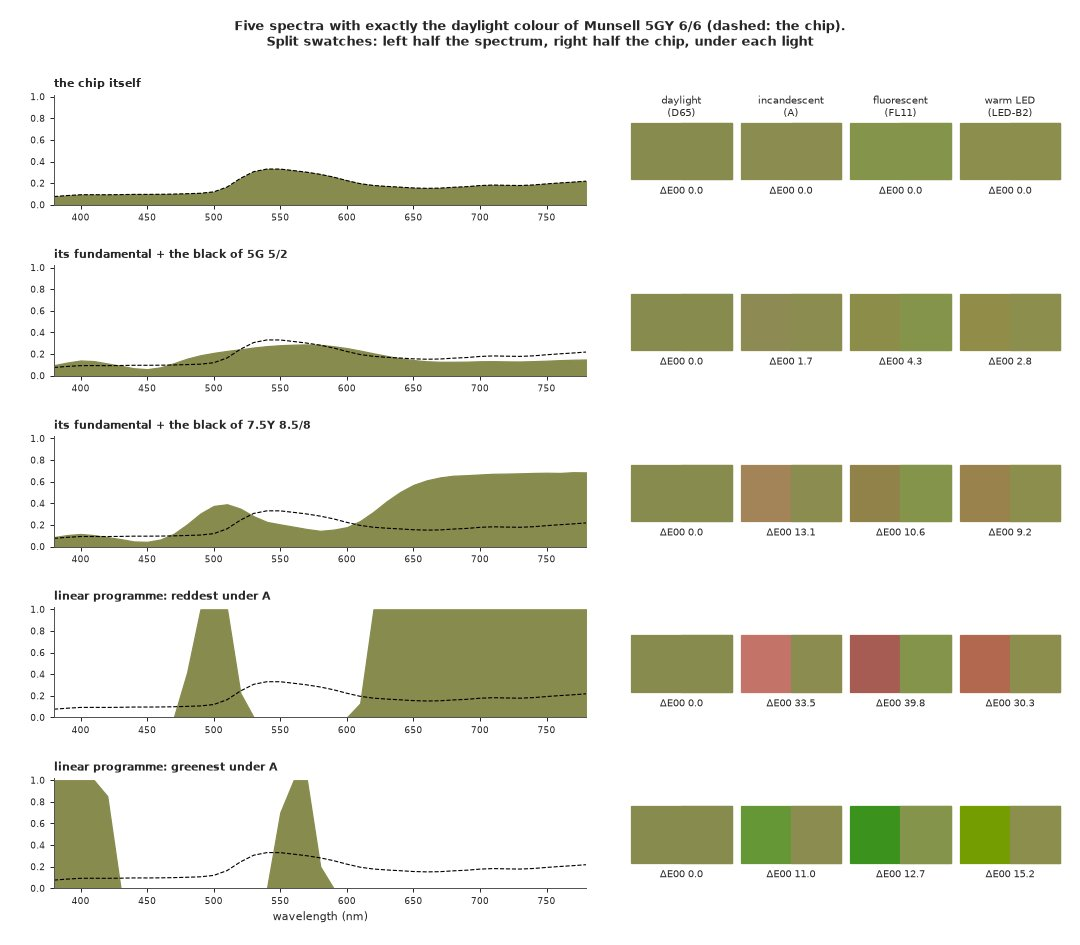

largest daylight ΔE00 between any of these and the chip: 3.9e-14


In [6]:
rng_b = np.random.default_rng(RANDOM_SEED + 1)
swaps = []
for j in rng_b.permutation(len(R_ALL)):
    Rm = fund + (R_ALL[j] - P_FUND @ R_ALL[j])
    if Rm.min() >= 0.01 and Rm.max() <= 0.99 and mun.hue_family[j] != mun.hue_family[focus]:
        swaps.append((mun.chip[j], Rm))
    if len(swaps) == 60:
        break


def lp_metamer(xyz_target, objective, lights=("D65",)):
    """Extreme metamer: optimise a linear objective over all 0 <= R <= 1 with the given colour(s)."""
    Aeq = np.vstack([W[k].T for k in lights])
    r = linprog(objective, A_eq=Aeq, b_eq=np.concatenate(xyz_target), bounds=[(0, 1)] * len(WL), method="highs")
    return r.x


x0 = R0 @ W["D65"]
redness_A = W["A"] @ np.array([1.0, -1.0, 0.0])              # X - Y under A: a proxy for a*
metamers = {"the chip itself": R0}
fl_shift = [de2000(lab(Rm, "FL11"), lab(R0, "FL11")) for _, Rm in swaps]
for i in np.argsort(fl_shift)[[len(swaps) // 2, -1]]:
    metamers[f"its fundamental + the black of {swaps[i][0]}"] = swaps[i][1]
metamers["linear programme: reddest under A"] = lp_metamer([x0], -redness_A)
metamers["linear programme: greenest under A"] = lp_metamer([x0], redness_A)

fig, axs = plt.subplots(len(metamers), 2, figsize=(12, 2.1 * len(metamers)),
                        gridspec_kw={"width_ratios": [1.2, 1]}, layout="none")
fig.subplots_adjust(hspace=0.55, left=0.05, right=0.99, top=0.9, bottom=0.06, wspace=0.08)
for r_, (name, Rm) in enumerate(metamers.items()):
    ax = axs[r_, 0]
    ax.fill_between(WL, 0, Rm, color=rgb(Rm))
    ax.plot(WL, R0, color="k", lw=0.9, ls="--")
    ax.set_ylim(0, 1.02)
    ax.set_xlim(380, 780)
    ax.set_title(name, fontsize=9, loc="left")
    ax.tick_params(labelsize=7)
    ax = axs[r_, 1]
    for c_, k in enumerate(LIGHTS):
        ax.add_patch(plt.Rectangle((c_, 0), 0.92, 1, color=rgb(Rm, k)))
        ax.add_patch(plt.Rectangle((c_ + 0.46, 0), 0.46, 1, color=rgb(R0, k)))
        dE = de2000(lab(Rm, k), lab(R0, k))
        ax.text(c_ + 0.46, -0.12, f"ΔE00 {dE:.1f}", ha="center", va="top", fontsize=8)
        if r_ == 0:
            ax.text(c_ + 0.46, 1.12, LIGHT_NAMES[k].replace(" (", "\n("), ha="center", fontsize=8)
    ax.set_xlim(-0.05, 4)
    ax.set_ylim(-0.45, 1.5)
    ax.axis("off")
axs[-1, 0].set_xlabel("wavelength (nm)", fontsize=9)
fig.suptitle(f"Five spectra with exactly the daylight colour of Munsell {mun.chip[focus]} (dashed: the chip).\n"
             "Split swatches: left half the spectrum, right half the chip, under each light", fontsize=10)
show_jpeg(fig)
print("largest daylight ΔE00 between any of these and the chip:",
      f"{max(de2000(lab(Rm), lab(R0)) for Rm in metamers.values()):.1e}")

All five are the same colour in daylight: the split swatches in the first column have no visible
seam, and ΔE00 is zero to rounding error. Under the other lights they come apart. The black of a
greyish green chip (5G 5/2) moves the colour by 2-4 ΔE00, the black of a yellow chip (7.5Y 8.5/8)
by 9-13, and the linear-programming extremes by 11 to 40, turning an olive yellow-green into
brick red or grass green.

### The metamer-mismatch body: every colour physics allows

Repeating the linear programme for many objectives (directions in XYZ under the second light) traces
the whole convex set of colours the chip's metamers can have there, the **metamer-mismatch body**.
It is the answer with *no* prior beyond $0 \le R \le 1$.

In [7]:
def mismatch_body(xyzs, light, lights=("D65",), n_dir=200, seed=0):
    """CIELAB under `light` of extreme metamers (0 <= R <= 1) matching the XYZ in `xyzs` under `lights`."""
    g = np.random.default_rng(seed)
    dirs = g.standard_normal((n_dir, 3))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    return xyz_to_lab(np.array([lp_metamer(xyzs, -(W[light] @ d), lights) @ W[light] for d in dirs]))


def hull_ab(lab_pts):
    h = ConvexHull(lab_pts[:, 1:])
    return lab_pts[np.r_[h.vertices, h.vertices[0]]][:, 1:]


t0 = time.time()
bodies = {k: mismatch_body([x0], k, n_dir=300) for k in ["A", "FL11", "LED_B2"]}
print(f"900 linear programmes in {time.time() - t0:.1f} s")
for k, b in bodies.items():
    print(f"{LIGHT_NAMES[k]:20s}: the most distant possible metamer is {de2000(b, lab(R0, k)).max():.0f} ΔE00 from the chip")

# real near-metamers inside the Munsell set
pairs = []
for i in range(len(R_ALL)):
    j = np.arange(i + 1, len(R_ALL))
    d = de2000(LAB["D65"][i], LAB["D65"][j])
    for jj in j[d < 1.0]:
        pairs.append((de2000(LAB["D65"][i], LAB["D65"][jj]), *[de2000(LAB[k][i], LAB[k][jj]) for k in ["A", "FL11", "LED_B2"]]))
pairs = pd.DataFrame(pairs, columns=["D65", "A", "FL11", "LED_B2"])
print(f"\n{len(pairs)} pairs of different Munsell chips are within ΔE00 < 1 of each other in daylight. Under the other lights:")
print(pairs.agg(["median", lambda x: x.quantile(0.9), "max"]).set_axis(["median", "90%", "max"]).round(2))

900 linear programmes in 0.5 s
incandescent (A)    : the most distant possible metamer is 34 ΔE00 from the chip
fluorescent (FL11)  : the most distant possible metamer is 59 ΔE00 from the chip
warm LED (LED-B2)   : the most distant possible metamer is 31 ΔE00 from the chip

64 pairs of different Munsell chips are within ΔE00 < 1 of each other in daylight. Under the other lights:
         D65     A  FL11  LED_B2
median  0.86  0.93  0.94    0.96
90%     0.97  1.16  1.37    1.21
max     1.00  2.98  3.27    2.86


Physics allows a metamer of this chip that is **59 ΔE00** away under FL11 (31-34 under the smooth
lights); these bodies are the grey regions in the figures of Part D. Real surfaces do not explore
that range. The Munsell set contains 64 pairs of different chips within ΔE00 1 of each other in
daylight, and under the other lights they hardly drift: their median difference goes from 0.86 to
0.93-0.96, the 90th percentile to 1.2-1.4 and the largest to 3. **Real metamerism is small compared
with what physics permits**, because real colourants have smooth, broad absorption bands. A useful
prior has to know this, and that is what Part C is about.

## C. Priors for spectra

Hold out a fifth of the chips (269) for validation and learn from the other 1,000. All priors
live on the **logit** of reflectance, $\eta(\lambda) = \log\{R/(1-R)\}$, so every draw is a valid
reflectance in (0, 1). Three candidates, all Gaussian on that scale:

1. **smooth GP** - "spectra are smooth, and that's all I know": a stationary GP over wavelength
   (squared-exponential kernel), with its mean, amplitude and length-scale fitted to the training
   chips by maximum marginal likelihood (so it is not a straw man: it is the best stationary
   smoothness prior for these data);
2. **learned** - the mean and full 41 x 41 covariance of the training chips' logit spectra. With 1,000
   chips and 41 dimensions the parameter uncertainty is negligible (the Normal-inverse-Wishart
   posterior predictive is a Student-t with about 960 degrees of freedom), so we plug the estimates
   in;
3. **3-component** - the classic *linear model* of surface reflectance (Maloney & Wandell 1986; the
   principal components of Munsell spectra were first studied by Parkkinen and colleagues in 1989):
   the mean plus three principal components. Three unknowns for three measured numbers, so the
   colour determines the spectrum exactly - no metamers at all.

In [8]:
rng_c = np.random.default_rng(RANDOM_SEED + 2)
perm = rng_c.permutation(len(R_ALL))
test_idx, train_idx = np.sort(perm[:269]), np.sort(perm[269:])


def logit(R):
    return np.log(R / (1 - R))


Zt = logit(R_ALL[train_idx])
MU, COV = Zt.mean(0), np.cov(Zt.T)
evals, evecs = np.linalg.eigh(COV)
evals, evecs = evals[::-1], evecs[:, ::-1]
print("cumulative share of logit-spectrum variance in the first principal components:",
      (np.cumsum(evals) / evals.sum())[:6].round(3))
DIFF = WL[:, None] - WL[None]


def gp_cov(amp, ell, nug):
    return amp**2 * np.exp(-0.5 * (DIFF / ell) ** 2) + nug**2 * np.eye(len(WL))


def gauss_nll(Z, m, K):
    Lk = np.linalg.cholesky(K)
    r = np.linalg.solve(Lk, (Z - m).T)
    return 0.5 * (r**2).sum() + Z.shape[0] * (np.log(np.diag(Lk)).sum() + 0.5 * len(WL) * np.log(2 * np.pi))


res = minimize(lambda p: gauss_nll(Zt, p[0], gp_cov(*np.exp(p[1:]))), [MU.mean(), 0, np.log(50), np.log(0.05)],
               method="Nelder-Mead", options={"maxiter": 4000, "xatol": 1e-4, "fatol": 1e-3})
GP_MEAN, (GP_AMP, GP_ELL, GP_NUG) = res.x[0], np.exp(res.x[1:])
print(f"smooth GP: mean logit {GP_MEAN:.2f} (R = {1 / (1 + np.exp(-GP_MEAN)):.2f}), amplitude {GP_AMP:.2f}, "
      f"length-scale {GP_ELL:.0f} nm, nugget {GP_NUG:.3f}")

PRIORS = {
    "smooth GP": dict(mean=np.full(len(WL), GP_MEAN), chol=np.linalg.cholesky(gp_cov(GP_AMP, GP_ELL, GP_NUG))),
    "learned": dict(mean=MU, chol=np.linalg.cholesky(COV + 1e-6 * np.eye(len(WL)))),
    "3-component": dict(mean=MU, chol=evecs[:, :3] * np.sqrt(evals[:3])),
}
PRIOR_COLORS = {"smooth GP": "C0", "learned": "C1", "3-component": "k"}
Zh = logit(R_ALL[test_idx])
for name in ["smooth GP", "learned"]:
    p = PRIORS[name]
    print(f"{name:10s}: log density of the 269 held-out spectra, per chip: "
          f"{-gauss_nll(Zh, p['mean'], p['chol'] @ p['chol'].T) / len(Zh):.1f}")


def prior_draws(name, n, seed=1):
    p = PRIORS[name]
    z = np.random.default_rng(seed).standard_normal((n, p["chol"].shape[1]))
    return 1 / (1 + np.exp(-(p["mean"] + z @ p["chol"].T)))

cumulative share of logit-spectrum variance in the first principal components: [0.778 0.93  0.984 0.993 0.996 0.997]


smooth GP: mean logit -1.21 (R = 0.23), amplitude 0.83, length-scale 26 nm, nugget 0.008
smooth GP : log density of the 269 held-out spectra, per chip: 44.0
learned   : log density of the 269 held-out spectra, per chip: 89.2


Three principal components carry 98% of the (logit) variance of the training chips, six carry
99.7%: the classic finding that surface spectra are low-dimensional. The fitted smoothness GP has
a length-scale of about 26 nm. On the 269 held-out spectra the learned prior is better by about **45
nats per chip**, an enormous margin (the 3-component model puts no density off its three-dimensional
subspace, so it cannot be scored this way).

**Prior predictive check.** What surfaces does each prior believe in? Draw spectra, look at their
shapes and their colours, next to real chips.

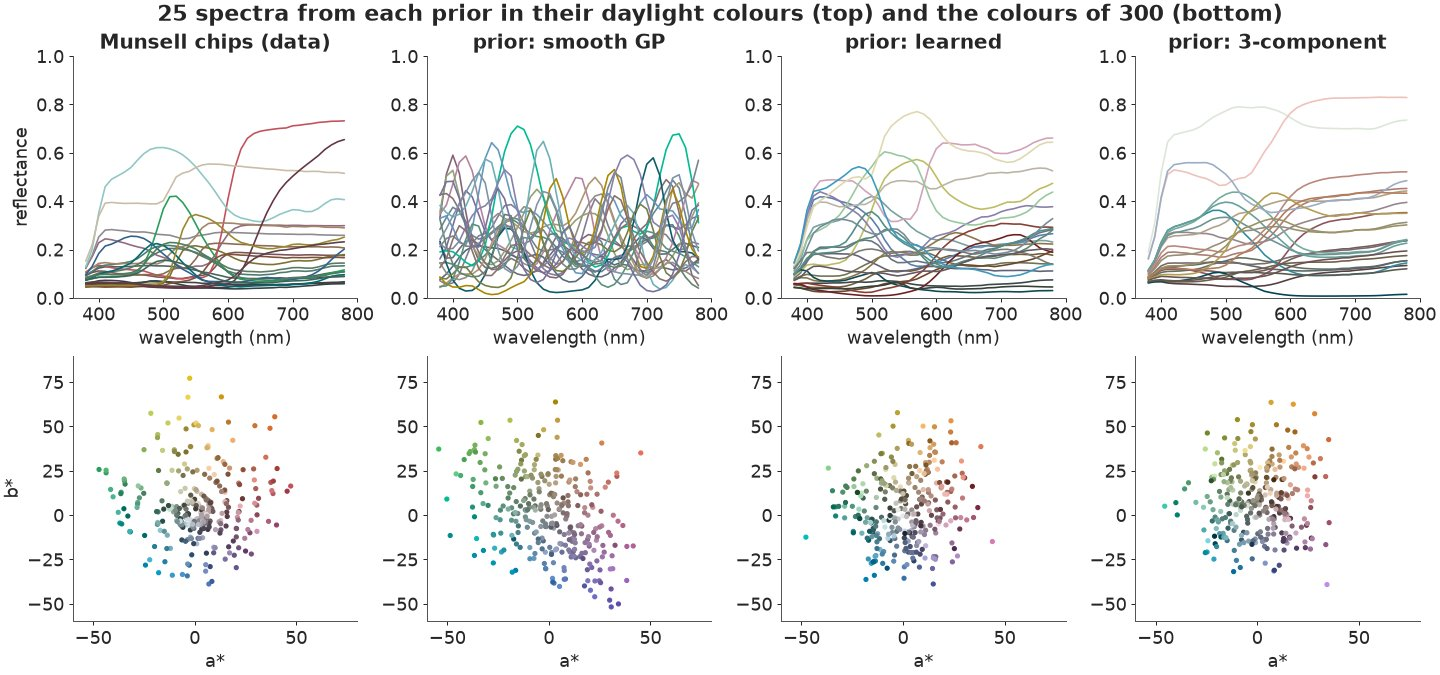

In [9]:
fig, axs = plt.subplots(2, 4, figsize=(16, 7.5), gridspec_kw={"height_ratios": [1, 1.1]})
show = {"Munsell chips (data)": R_ALL[rng.choice(len(R_ALL), 300, replace=False)]}
show.update({f"prior: {k}": prior_draws(k, 300) for k in PRIORS})
for c_, (name, Rs) in enumerate(show.items()):
    for Rm in Rs[:25]:
        axs[0, c_].plot(WL, Rm, color=rgb(Rm), lw=1.3)
    axs[0, c_].set_ylim(0, 1)
    axs[0, c_].set_title(name)
    axs[0, c_].set_xlabel("wavelength (nm)")
    L_ = lab(Rs)
    axs[1, c_].scatter(L_[:, 1], L_[:, 2], c=lab_to_srgb(L_), s=10)
    axs[1, c_].set_xlim(-60, 80)
    axs[1, c_].set_ylim(-60, 90)
    axs[1, c_].set_xlabel("a*")
axs[0, 0].set_ylabel("reflectance")
axs[1, 0].set_ylabel("b*")
fig.suptitle("25 spectra from each prior in their daylight colours (top) and the colours of 300 (bottom)")
show_jpeg(fig)

The smoothness GP produces wiggly curves with several bumps, nothing like a paint, and a colour
cloud that reaches further into purples and blues than any chip. The learned prior's draws look like
real chips: smooth, one or two broad features, low in the violet; their colour cloud is a little more
compact than the chips' (fewer vivid yellows), since a single Gaussian cannot follow the edges of the
set exactly. The 3-component draws look just as realistic - the difference will only show in the
posterior.

### A closed-form preview: how much can one colour tell?

Before any sampling, a linear-Gaussian calculation tells how much of a prior's uncertainty a colour
measurement can remove. Approximate each prior by a Gaussian *on reflectance* (moments of its
draws) and observe XYZ with tiny noise: the posterior covariance is the prior's minus a rank-3
update, in closed form. The share of the prior's total variance that survives is a one-number summary
of "how big the metamer set is, relative to the prior".

In [10]:
XYZ_SD = 0.002


def variance_left(C, lights):
    G = np.vstack([W[k].T for k in lights])
    S_ = G @ C @ G.T + XYZ_SD**2 * np.eye(len(G))
    return np.trace(C - C @ G.T @ np.linalg.solve(S_, G @ C)) / np.trace(C)


prior_R_cov = {k: np.cov(prior_draws(k, 20000, seed=5).T) for k in ["smooth GP", "learned"]}
print(pd.DataFrame({k: {"daylight": variance_left(C, ["D65"]), "daylight + incandescent": variance_left(C, ["D65", "A"])}
                    for k, C in prior_R_cov.items()}).round(3).rename_axis("measured under"))

                         smooth GP  learned
measured under                             
daylight                     0.610    0.044
daylight + incandescent      0.457    0.029


One daylight colour removes **96%** of the learned prior's variance but only 39% of the smoothness
GP's: real spectra vary mostly in directions the eye *can* see, so the learned prior's metamer set is
small. The GP spreads its variance evenly over wavelengths, in combinations the eye
cannot separate. A second light helps both, but the GP stays vague. (The approximation ignores the
logit and CIELAB non-linearities; PyMC does not need to.)

## D. Inverting colour to spectrum in PyMC

The model for one chip, with logit-reflectance $\eta$ drawn from a prior with mean $m$ and Cholesky
factor $L$:

$$z \sim \mathcal N(0, I), \qquad R = \operatorname{logit}^{-1}(m + L z), \qquad
y_{\text{light}} \sim \mathcal N\big(\text{Lab}_{\text{light}}(R),\ 0.5^2 I\big).$$

The observation is a colorimeter reading: we **simulate** it from each held-out chip's measured
spectrum, adding noise with a standard deviation of 0.5 CIELAB units per coordinate (a typical
instrument-to-instrument agreement). Chips are independent, so 96 of the held-out chips go into
**one** model with a `chip` dimension: one compilation and one sampler run instead of 96.

In [11]:
SIGMA_LAB = 0.5
N_VAL = 96
rng_d = np.random.default_rng(RANDOM_SEED + 3)
val = test_idx[rng_d.choice(len(test_idx), N_VAL, replace=False)]
Y_OBS = {k: lab(R_ALL[val], k) + SIGMA_LAB * rng_d.standard_normal((N_VAL, 3)) for k in ["D65", "A"]}
coords = {"chip": mun.chip[val].to_numpy(dtype=object), "wl": WL, "lab": ["L", "a", "b"]}


def invert(prior, lights=("D65",), thin=4):
    """Posterior spectra of all validation chips given their colour under `lights`: (draw, chip, wl)."""
    p = PRIORS[prior]
    with pm.Model(coords={**coords, "k": np.arange(p["chol"].shape[1])}) as m:
        z = pm.Normal("z", 0, 1, dims=("chip", "k"))
        R = pm.Deterministic("R", pm.math.sigmoid(p["mean"] + z @ p["chol"].T), dims=("chip", "wl"))
        for k in lights:
            pm.Normal(f"y_{k}", lab_pt(R, W[k]), SIGMA_LAB, observed=Y_OBS[k], dims=("chip", "lab"))
        t0 = time.time()
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    st = idata.sample_stats
    print(f"{prior:11s} | {'+'.join(lights):6s}: {time.time() - t0:3.0f} s, divergences {int(st['diverging'].sum())}, "
          f"mean tree depth {float(st['depth'].mean()):.1f}, max r_hat(R) {float(az.rhat(idata.posterior['R']).max()):.3f}, "
          f"min bulk ESS(R) {float(az.ess(idata.posterior['R']).min()):.0f}")
    return idata.posterior["R"].isel(draw=slice(None, None, thin)).stack(s=("chain", "draw")).transpose("s", "chip", "wl").values


post = {}
for prior in PRIORS:
    post[(prior, "D65")] = invert(prior)

smooth GP   | D65   :  47 s, divergences 0, mean tree depth 8.6, max r_hat(R) 1.006, min bulk ESS(R) 3163


learned     | D65   :  29 s, divergences 0, mean tree depth 8.0, max r_hat(R) 1.004, min bulk ESS(R) 1684


3-component | D65   :   2 s, divergences 0, mean tree depth 4.0, max r_hat(R) 1.007, min bulk ESS(R) 3903


All three samplers are healthy: no divergences, r_hat at most 1.01, and at least about 1,700
effective draws for every one of the 96 x 41 reflectances. The tree depth of 8 (255 gradient steps
per draw) for the two full priors is the geometry of the problem: in each chip 3 of 41 directions are
pinned down to within the measurement noise and 38 are held only by the prior, a condition number that
a diagonal mass matrix cannot remove because the pinned directions are not aligned with the
coordinates. (nutpie's low-rank mass matrix did not help: in a trial on 20 chips it was 7 and 25
times slower, with hundreds of divergences for the GP prior.)

How wide is each posterior, and how close is its centre to the truth, under each light?

In [12]:
def spread(Rd, light):
    """Median ΔE00 between posterior draws and the posterior-median colour, per chip."""
    L_ = lab(Rd, light)
    return np.median(de2000(L_, np.median(L_, 0)), 0)


TRUE = {k: lab(R_ALL[val], k) for k in LIGHTS}
rows = []
for (prior, obs), Rd in post.items():
    for k in LIGHTS:
        rows.append((prior, LIGHT_NAMES[k], np.median(spread(Rd, k)), np.median(de2000(np.median(lab(Rd, k), 0), TRUE[k]))))
tab = pd.DataFrame(rows, columns=["prior", "light", "spread", "error"])
print("median over chips of (posterior spread | error of the posterior median), ΔE00, colour observed in daylight:")
print(tab.pivot(index="light", columns="prior").reindex([LIGHT_NAMES[k] for k in LIGHTS]).round(2))

median over chips of (posterior spread | error of the posterior median), ΔE00, colour observed in daylight:
                        spread                         error                  
prior              3-component learned smooth GP 3-component learned smooth GP
light                                                                         
daylight (D65)            0.60    0.60      0.59        0.64    0.65      0.66
incandescent (A)          0.63    1.15      2.86        1.08    0.98      1.93
fluorescent (FL11)        0.60    1.41      5.24        1.19    1.17      1.49
warm LED (LED-B2)         0.62    1.14      3.53        1.05    1.05      1.44


In daylight, where the colour was measured, all three priors agree: spread and error about 0.6, the
measurement noise. Under the other lights they part ways:

* the **smooth GP** is vague (a spread of 3-5 ΔE00) and its best guess is off by 1.4-1.9;
* the **learned** prior is sharp (spread 1.1-1.4) and its best guess is off by 1.0-1.2;
* the **3-component** model is the sharpest (0.6: it believes only in the measurement noise), but its
  best guess is *no better* than the learned prior's. Its certainty is not information; Part E
  measures how misleading it is.

### Posterior spectra, drawn in the colour they show under another light

Two held-out chips: the one where the GP and the learned prior disagree most about FL11 (a bluish
grey, 10PB 6/1), and a typical colourful one (a green, 2.5G 6/8). Each thin line is one posterior
spectrum, drawn in the colour it would show **under the fluorescent FL11**. In daylight all of them
have (within the noise) the same colour; the spread of line colours is the metamer mismatch.

{'10PB 6/1': 'FL11 spread: GP 9.2, learned 2.3', '2.5G 6/8': 'FL11 spread: GP 4.2, learned 1.1'}


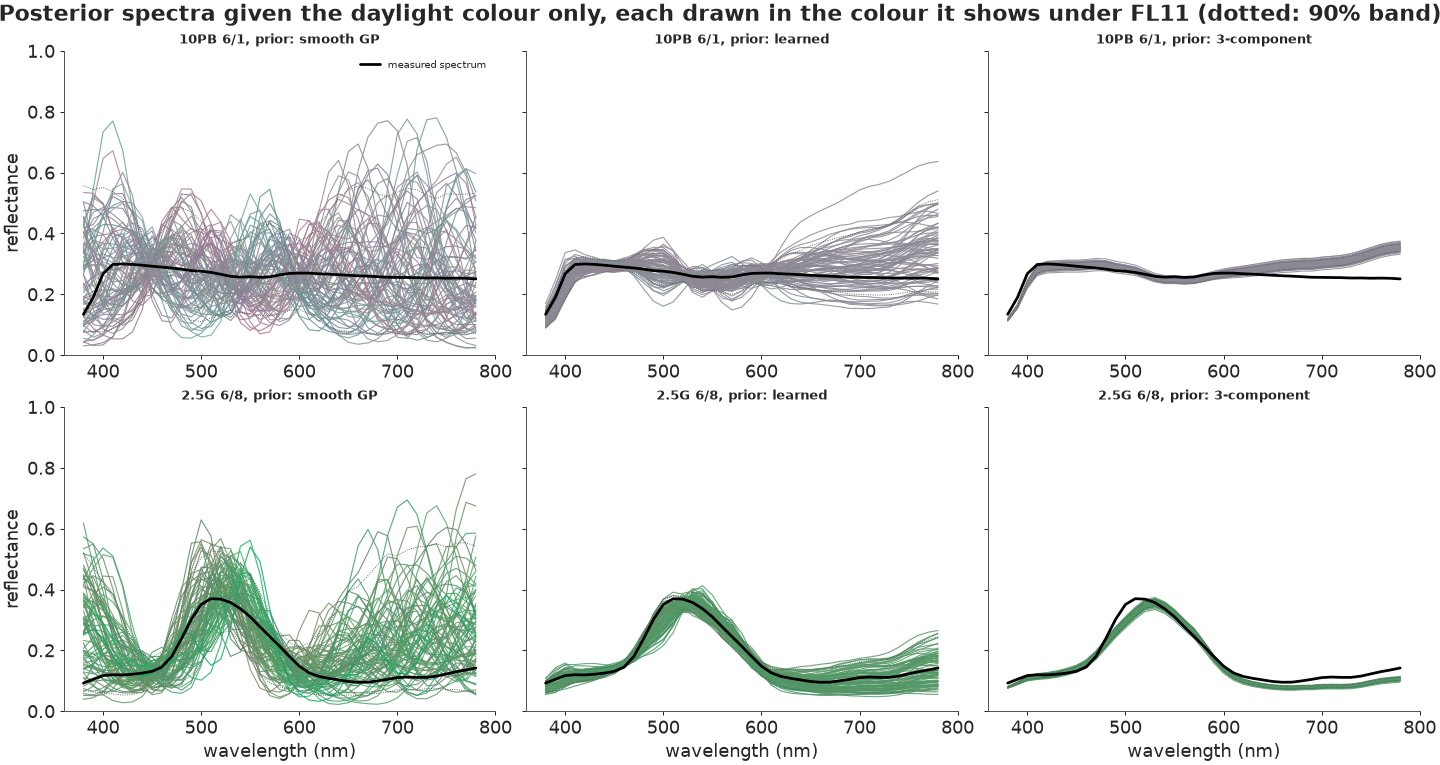

In [13]:
gp_sp, le_sp = spread(post[("smooth GP", "D65")], "FL11"), spread(post[("learned", "D65")], "FL11")
colourful = np.flatnonzero(mun.chroma.to_numpy()[val] >= 6)
SHOW = [int(np.argmax(gp_sp - le_sp)), int(colourful[np.argsort(le_sp[colourful])[len(colourful) // 2]])]
print({mun.chip[val[i]]: f"FL11 spread: GP {gp_sp[i]:.1f}, learned {le_sp[i]:.1f}" for i in SHOW})

fig, axs = plt.subplots(2, 3, figsize=(16, 8.5), sharey=True)
for r_, i in enumerate(SHOW):
    for c_, prior in enumerate(PRIORS):
        ax = axs[r_, c_]
        Rd = post[(prior, "D65")][:, i]
        for Rm, cl in zip(Rd[:80], rgb(Rd[:80], "FL11")):
            ax.plot(WL, Rm, color=cl, lw=0.9, alpha=0.85)
        lo, hi = np.quantile(Rd, [0.05, 0.95], 0)
        ax.plot(WL, lo, color="0.3", lw=0.7, ls=":")
        ax.plot(WL, hi, color="0.3", lw=0.7, ls=":")
        ax.plot(WL, R_ALL[val[i]], color="k", lw=2.2, label="measured spectrum")
        ax.set_title(f"{mun.chip[val[i]]}, prior: {prior}", fontsize=10)
        ax.set_ylim(0, 1)
    axs[r_, 0].set_ylabel("reflectance")
axs[0, 0].legend(fontsize=8)
for ax in axs[1]:
    ax.set_xlabel("wavelength (nm)")
fig.suptitle("Posterior spectra given the daylight colour only, each drawn in the colour it shows under FL11 (dotted: 90% band)")
show_jpeg(fig)

The GP's metamers are anything smooth enough with the right colour: bumpy curves that cross the
true spectrum everywhere, and whose FL11 colours range from pink to teal for the grey chip. The
learned prior's metamers hug the true spectrum below 600 nm and fan out mostly above 650 nm, where the
eye is weakest (and where the prior, not the measurement, decides). The 3-component posterior is a
thin ribbon, and it misses: above the true spectrum beyond 650 nm for the grey chip, below the green
chip's peak and its long-wavelength tail. Confidently wrong.

### Swatch fans: the same posterior under four lights

A spectrum is abstract; a swatch is what a client looks at. Cut each swatch into 40 vertical strips,
one posterior draw each, sorted by hue, rendered under each light. A uniform swatch means a certain
colour; a striped one means the metamers disagree under that light, and the stripes show *how*
they disagree. The small inner square is the real chip.

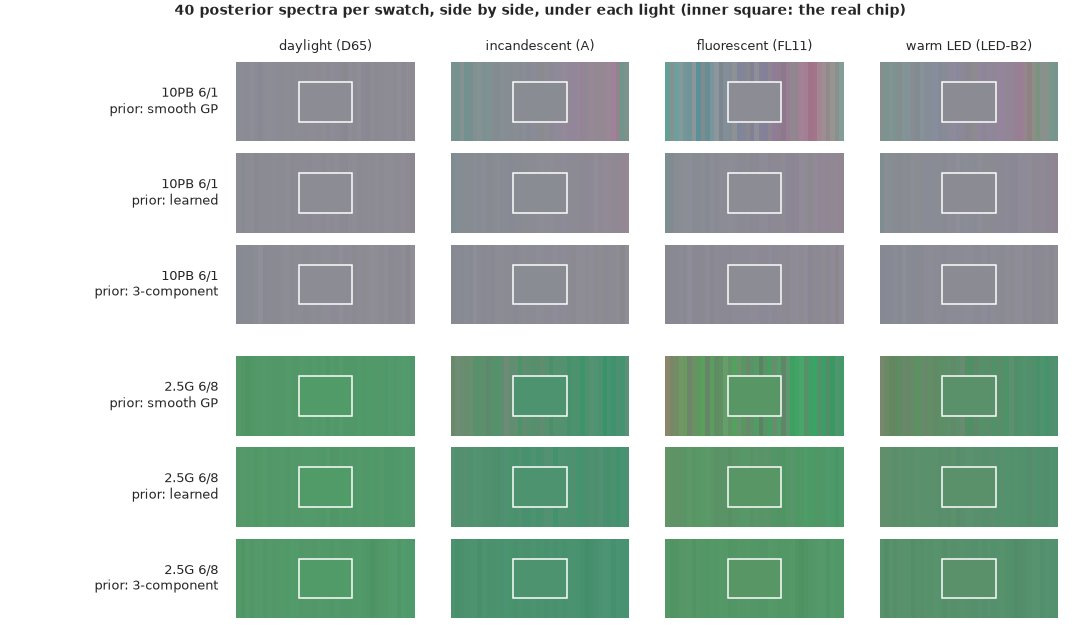

In [14]:
def swatch_fan(ax, Rd, light, x0_, y0_, w=1.0, h=1.0, n=40, truth=None):
    """A swatch cut into n vertical strips, one posterior draw each, ordered by hue under the light."""
    L_ = lab(Rd[:n], light)
    cols = lab_to_srgb(L_[np.argsort(np.arctan2(L_[:, 2], L_[:, 1]))])
    for s_, c in enumerate(cols):
        ax.add_patch(plt.Rectangle((x0_ + s_ * w / n, y0_), w / n * 1.02, h, color=c, lw=0))
    if truth is not None:
        ax.add_patch(plt.Rectangle((x0_ + 0.35 * w, y0_ + 0.25 * h), 0.3 * w, 0.5 * h, facecolor=rgb(truth, light),
                                   edgecolor="white", lw=1.2))


fig, ax = plt.subplots(figsize=(12, 7))
for r_, i in enumerate(SHOW):
    for p_, prior in enumerate(PRIORS):
        y = -(r_ * 3.7 + p_ * 1.15)
        for c_, k in enumerate(LIGHTS):
            swatch_fan(ax, post[(prior, "D65")][:, i], k, c_ * 1.2, y, truth=R_ALL[val[i]])
        ax.text(-0.1, y + 0.5, f"{mun.chip[val[i]]}\nprior: {prior}", ha="right", va="center", fontsize=10)
for c_, k in enumerate(LIGHTS):
    ax.text(c_ * 1.2 + 0.5, 1.15, LIGHT_NAMES[k], ha="center", fontsize=10)
ax.set_xlim(-1.3, 4.7)
ax.set_ylim(-6.1, 1.5)
ax.axis("off")
ax.set_title("40 posterior spectra per swatch, side by side, under each light (inner square: the real chip)", fontsize=11)
show_jpeg(fig)

In daylight every swatch is flat: the colour was measured. Under FL11 the GP's swatches become
barcodes (teal to pink for the grey chip, brown to bright green for the green one); the learned
prior's show a gentle gradient that contains the real chip; the 3-component swatches stay flat under
every light, which is exactly the problem.

### Mismatch clouds against the physical limit

The same posteriors as points in the a*b* plane under each light, with 90% ellipses, inside the
metamer-mismatch body (grey) - everything physics allows for a spectrum with this daylight colour.
The main panels zoom on the posteriors; the insets show the whole body, with the zoomed window as a
rectangle.

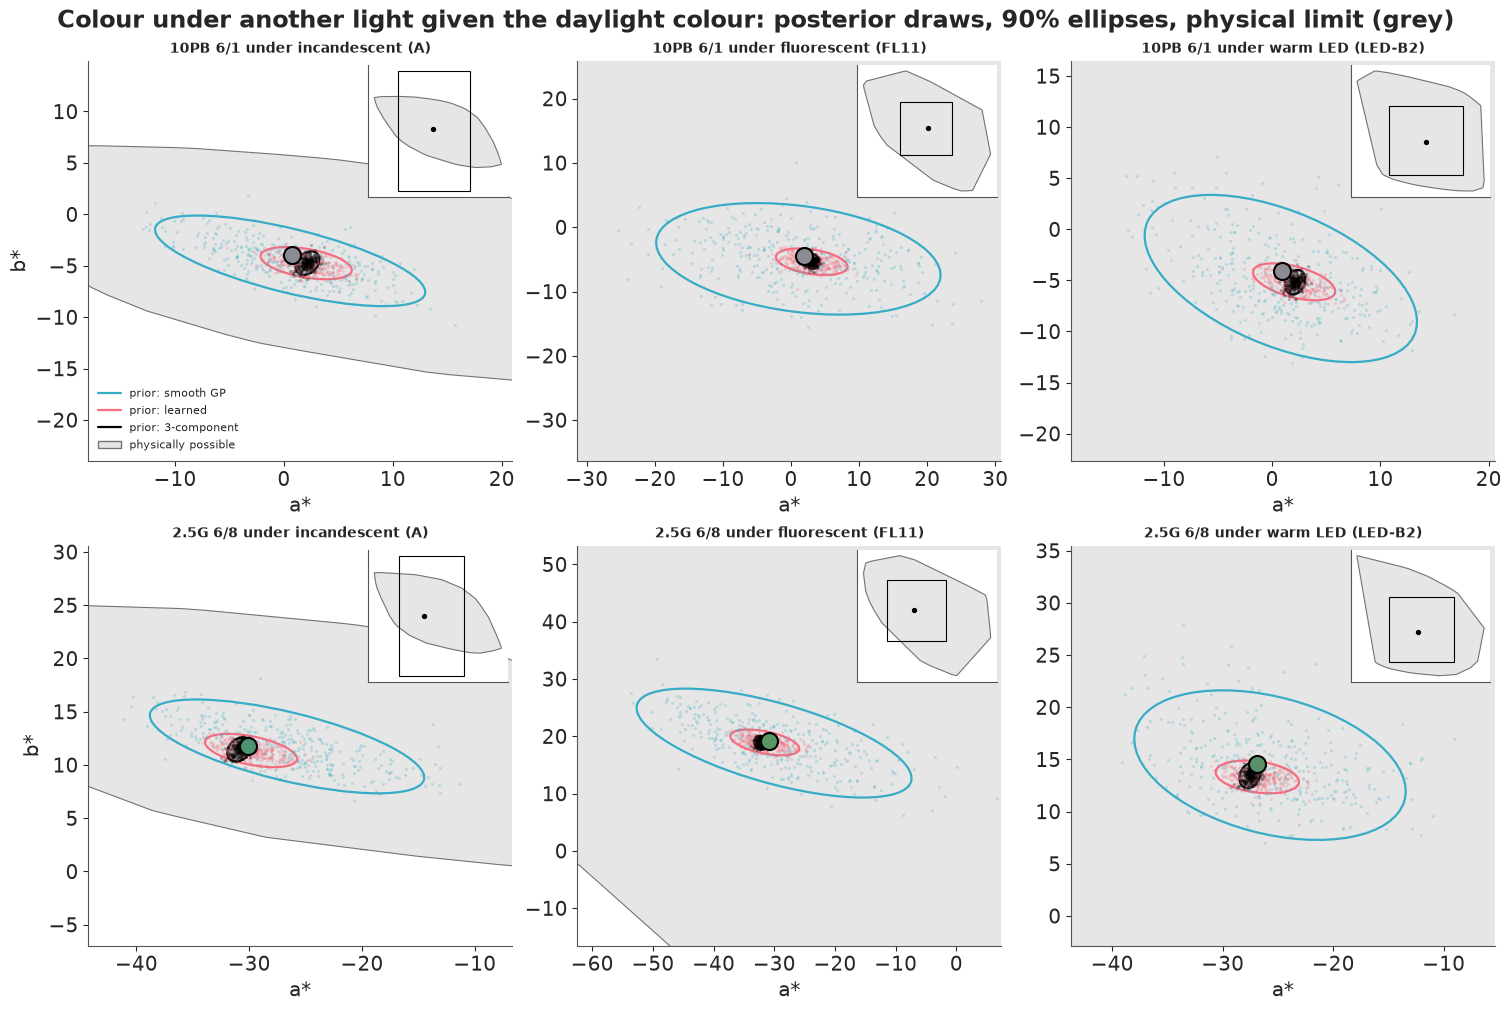

In [15]:
def ellipse(ax, pts, color, ls="-", lw=1.6, prob=0.9):
    c = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(c)
    k = np.sqrt(-2 * np.log(1 - prob))
    ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax.add_patch(Ellipse(pts.mean(0), 2 * k * np.sqrt(vals[1]), 2 * k * np.sqrt(vals[0]), angle=ang,
                         fill=False, color=color, ls=ls, lw=lw))


def cloud_panel(ax, i, light, posts, body_sets, zoom_from):
    """posts: {label: (draws, colour)}; body_sets: [(xyz list, lights, fill)]."""
    t = lab(R_ALL[val[i]], light)
    ins = ax.inset_axes([0.66, 0.66, 0.33, 0.33])
    for xyzs, lights_, fc in body_sets:
        hb = hull_ab(mismatch_body(xyzs, light, lights_))
        for a_ in (ax, ins):
            a_.fill(hb[:, 0], hb[:, 1], color=fc, ec="0.45", lw=0.8, zorder=0)
    for label, (Rd, col) in posts.items():
        L_ = lab(Rd, light)[:, 1:]
        ax.scatter(L_[::3, 0], L_[::3, 1], s=5, color=col, alpha=0.25, lw=0, zorder=2)
        ellipse(ax, L_, col)
        ax.plot([], [], color=col, lw=1.6, label=label)
    ax.scatter(t[1], t[2], s=150, color=lab_to_srgb(t), edgecolor="k", lw=1.5, zorder=5)
    Z_ = lab(zoom_from, light)[:, 1:]
    lo_, hi_ = np.quantile(Z_, [0.005, 0.995], 0)
    pad = 0.15 * (hi_ - lo_).max() + 1
    ctr, half = (lo_ + hi_) / 2, (hi_ - lo_).max() / 2 + pad
    ax.set_xlim(ctr[0] - half, ctr[0] + half)
    ax.set_ylim(ctr[1] - half, ctr[1] + half)
    ins.add_patch(plt.Rectangle(ctr - half, 2 * half, 2 * half, fill=False, color="k", lw=0.8))
    ins.scatter(t[1], t[2], s=8, color="k")
    ins.set_xticks([])
    ins.set_yticks([])
    ax.set_title(f"{mun.chip[val[i]]} under {LIGHT_NAMES[light]}", fontsize=10)
    ax.set_xlabel("a*")


fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for r_, i in enumerate(SHOW):
    xi = [R_ALL[val[i]] @ W["D65"]]
    for c_, k in enumerate(["A", "FL11", "LED_B2"]):
        cloud_panel(axs[r_, c_], i, k, {f"prior: {p}": (post[(p, "D65")][:, i], PRIOR_COLORS[p]) for p in PRIORS},
                    [(xi, ("D65",), "0.9")], zoom_from=post[("smooth GP", "D65")][:, i])
    axs[r_, 0].set_ylabel("b*")
h_, l_ = axs[0, 0].get_legend_handles_labels()
axs[0, 0].legend(h_ + [Patch(color="0.9", ec="0.45")], l_ + ["physically possible"], fontsize=8, loc="lower left")
fig.suptitle("Colour under another light given the daylight colour: posterior draws, 90% ellipses, physical limit (grey)");

The physical bodies are enormous (the insets), and every posterior sits in a small region inside
them: the prior is doing nearly all of the work. The GP's ellipses are several times the learned
prior's in each direction, and the 3-component clouds are tiny. In all six panels the real colour
sits inside the learned prior's 90% ellipse; it sits at the edge of, or outside, the 3-component
cloud in most. All the clouds are elongated: the metamers of a chip differ mostly along one
direction of the a*b* plane.

## E. Is the posterior honest? Calibration on held-out chips

Every one of the 96 chips has a measured spectrum, so every prediction can be checked. For each chip
and each coordinate (L*, a*, b*) under each light, compute the **PIT**, the share of posterior draws
below the true value; for a calibrated posterior it is uniform, and a central interval of nominal
probability $p$ contains the truth a share $p$ of the time. For the spectrum, check how often the
true reflectance falls inside the 90% band, wavelength by wavelength.

In [16]:
LEVELS = np.array([0.5, 0.8, 0.9, 0.95])


def coverage(Rd, light):
    pit = (lab(Rd, light) < TRUE[light][None]).mean(0)                   # chip x 3
    return np.array([(np.abs(pit - 0.5) <= lv / 2).mean() for lv in LEVELS]), pit


def spectral_coverage(Rd, level=0.9):
    lo, hi = np.quantile(Rd, [(1 - level) / 2, (1 + level) / 2], 0)
    return ((R_ALL[val] >= lo) & (R_ALL[val] <= hi)).mean()


cov_rows = []
for prior in PRIORS:
    Rd = post[(prior, "D65")]
    for k in ["A", "FL11", "LED_B2"]:
        cov_rows.append((prior, f"colour under {k}", *coverage(Rd, k)[0]))
    cov_rows.append((prior, "spectrum (per wavelength)", np.nan, np.nan, spectral_coverage(Rd), np.nan))
print(f"share of truths inside central posterior intervals ({N_VAL} held-out chips, colour observed in daylight):")
print(pd.DataFrame(cov_rows, columns=["prior", "target", *[f"{int(100 * l)}%" for l in LEVELS]]).round(2).to_string(index=False))

share of truths inside central posterior intervals (96 held-out chips, colour observed in daylight):
      prior                    target  50%  80%  90%  95%
  smooth GP            colour under A 0.68 0.91 0.94 0.99
  smooth GP         colour under FL11 0.94 0.99 1.00 1.00
  smooth GP       colour under LED_B2 0.81 0.97 0.98 0.99
  smooth GP spectrum (per wavelength)  NaN  NaN 0.90  NaN
    learned            colour under A 0.56 0.84 0.93 0.97
    learned         colour under FL11 0.58 0.84 0.92 0.94
    learned       colour under LED_B2 0.55 0.84 0.93 0.97
    learned spectrum (per wavelength)  NaN  NaN 0.94  NaN
3-component            colour under A 0.37 0.62 0.74 0.80
3-component         colour under FL11 0.30 0.55 0.66 0.72
3-component       colour under LED_B2 0.36 0.62 0.71 0.77
3-component spectrum (per wavelength)  NaN  NaN 0.37  NaN


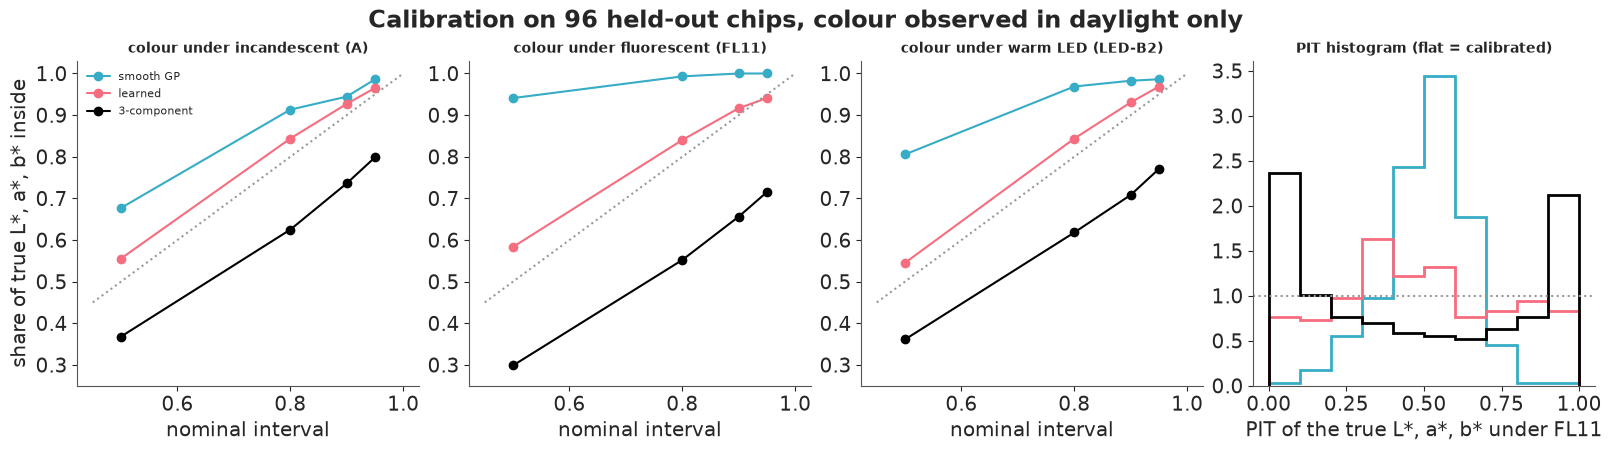

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.4))
for c_, k in enumerate(["A", "FL11", "LED_B2"]):
    ax = axs[c_]
    for prior in PRIORS:
        ax.plot(LEVELS, coverage(post[(prior, "D65")], k)[0], "o-", color=PRIOR_COLORS[prior], label=prior)
    ax.plot([0.45, 1], [0.45, 1], color="0.6", ls=":")
    ax.set_title(f"colour under {LIGHT_NAMES[k]}", fontsize=10)
    ax.set_xlabel("nominal interval")
    ax.set_ylim(0.25, 1.03)
axs[0].set_ylabel("share of true L*, a*, b* inside")
axs[0].legend(fontsize=8)
ax = axs[3]
for prior in PRIORS:
    ax.hist(coverage(post[(prior, "D65")], "FL11")[1].ravel(), bins=np.linspace(0, 1, 11), histtype="step", lw=2,
            color=PRIOR_COLORS[prior], density=True, label=prior)
ax.axhline(1, color="0.6", ls=":")
ax.set_xlabel("PIT of the true L*, a*, b* under FL11")
ax.set_title("PIT histogram (flat = calibrated)", fontsize=10)
fig.suptitle(f"Calibration on {N_VAL} held-out chips, colour observed in daylight only");

**The learned prior is calibrated**, if anything slightly conservative: its 50/80/90/95% intervals
for the colour under each of the three other lights contain the truth 55-58%, 84%, 92-93% and 94-97%
of the time, and its 90% spectral bands contain the true reflectance at 94% of wavelengths. Its PIT
histogram is flat up to a mild excess in the middle (288 values: 96 chips x 3 coordinates).

**The smooth GP is honest but not useful**: its intervals are far too *wide* (the 50% intervals contain
the truth 68-94% of the time, and the PIT piles up in the middle). Nothing it says is false, but
"somewhere within 5 ΔE00" under FL11 is not a prediction anyone can act on.

**The 3-component model is the failure of this notebook.** Its nominal 90% intervals contain the
truth 66-74% of the time and its 95% intervals 72-80%; its 90% spectral bands contain the true
spectrum at only 37% of wavelengths; its PIT histogram is U-shaped, the signature of
overconfidence. The classic linear model is not wrong about the *centre* (Part D: its error is
close to the learned prior's), it is wrong about its *uncertainty*: the real chip's spectrum has
components outside the three-dimensional subspace, and those are exactly the metameric blacks that
make colours drift under other lights.
**The fix is to keep all the dimensions and let a learned prior shrink them**, rather than truncate
them to zero.

### Where is the posterior confident, and where is it honest?

Two questions per chip. *How wide* is the posterior under FL11? And *how surprising* is the truth: a
ΔE00-based PIT, the share of posterior draws closer to the posterior-median colour than the true
colour is (uniform if calibrated; above 0.9 means the truth lies outside the 90% "ball").

rank correlation, spread vs chroma: GP -0.76, learned -0.80
learned prior: median ΔE00-PIT 0.32; > 0.9 (truth outside the 90% ball) under FL11: 11% of chips; among the quarter with the most unusual spectra 25%, among the rest 7%


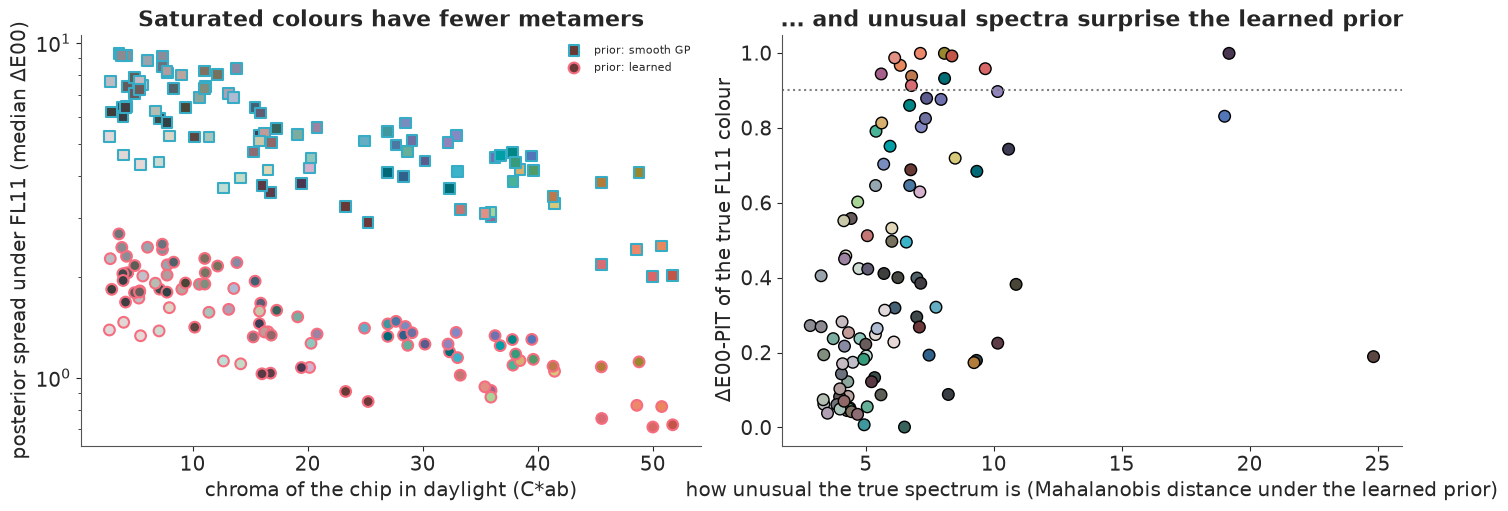

In [18]:
chroma = np.hypot(TRUE["D65"][:, 1], TRUE["D65"][:, 2])
maha = np.linalg.norm(np.linalg.solve(PRIORS["learned"]["chol"], (logit(R_ALL[val]) - MU).T), axis=0)


def radial_pit(Rd, light):
    L_ = lab(Rd, light)
    med = np.median(L_, 0)
    return (de2000(L_, med) < de2000(TRUE[light], med)[None]).mean(0)


fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for prior, mk in [("smooth GP", "s"), ("learned", "o")]:
    axs[0].scatter(chroma, spread(post[(prior, "D65")], "FL11"), c=rgb(R_ALL[val]), marker=mk, s=60,
                   edgecolor=PRIOR_COLORS[prior], lw=1.5, label=f"prior: {prior}")
axs[0].set_yscale("log")
axs[0].set_xlabel("chroma of the chip in daylight (C*ab)")
axs[0].set_ylabel("posterior spread under FL11 (median ΔE00)")
axs[0].legend(fontsize=8)
axs[0].set_title("Saturated colours have fewer metamers")
rp = radial_pit(post[("learned", "D65")], "FL11")
axs[1].scatter(maha, rp, c=rgb(R_ALL[val]), s=70, edgecolor="k")
axs[1].axhline(0.9, color="0.5", ls=":")
axs[1].set_xlabel("how unusual the true spectrum is (Mahalanobis distance under the learned prior)")
axs[1].set_ylabel("ΔE00-PIT of the true FL11 colour")
axs[1].set_title("... and unusual spectra surprise the learned prior")
print(f"rank correlation, spread vs chroma: GP {pd.Series(chroma).corr(pd.Series(gp_sp), method='spearman'):.2f}, "
      f"learned {pd.Series(chroma).corr(pd.Series(le_sp), method='spearman'):.2f}")
print(f"learned prior: median ΔE00-PIT {np.median(rp):.2f}; > 0.9 (truth outside the 90% ball) under FL11: {(rp > 0.9).mean():.0%} of chips; "
      f"among the quarter with the most unusual spectra {(rp[maha >= np.quantile(maha, 0.75)] > 0.9).mean():.0%}, "
      f"among the rest {(rp[maha < np.quantile(maha, 0.75)] > 0.9).mean():.0%}")

**Confidence follows chroma.** The more saturated the colour, the smaller the posterior, under both
priors (rank correlation about -0.8): a colour near the edge of what surfaces can reach has few ways to
be made, and at the very edge (the block spectra of Part B) exactly one. Greyish, low-chroma chips are
the ones whose colour under another light is least predictable. This is a property of the problem,
not of a prior.

**Honesty follows typicality.** Overall the truth falls outside the learned posterior's 90% ball for
about 11% of chips, as it should. But those misses concentrate among the chips whose true spectra are
most unusual *for the prior* (the right-hand quarter of the panel: about a quarter missed, against 7%
for the rest), while for typical chips the ΔE00-PIT leans towards small values (its median over all
chips is 0.32 rather than 0.5: the truth tends to be closer to the centre than the posterior
expects, so for typical surfaces the learned posterior is somewhat conservative). That is the
limitation of any learned prior: a surface made with a colourant the training set does not contain
(a fluorescent ink, an unusual dye) will be predicted confidently and wrongly. The posterior is
calibrated *for surfaces like those it learned from*.

## F. One light or two?

A colorimeter can often measure under a second light. Measure every held-out chip under incandescent
light (A) as well, 6 numbers instead of 3, and predict the colour under FL11 and the LED.

In [19]:
post[("learned", "D65+A")] = invert("learned", ("D65", "A"))
rows = []
for obs in ["D65", "D65+A"]:
    Rd = post[("learned", obs)]
    for k in ["FL11", "LED_B2"]:
        rows.append((obs, f"colour under {k}", np.median(spread(Rd, k)), coverage(Rd, k)[0][2]))
    rows.append((obs, "spectrum", np.median(np.diff(np.quantile(Rd, [0.05, 0.95], 0), axis=0)), spectral_coverage(Rd)))
print(pd.DataFrame(rows, columns=["observed under", "predicted", "median spread (ΔE00) or 90% band width", "90% coverage"])
      .round(3).to_string(index=False))

learned     | D65+A :  64 s, divergences 0, mean tree depth 9.0, max r_hat(R) 1.005, min bulk ESS(R) 3522


observed under           predicted  median spread (ΔE00) or 90% band width  90% coverage
           D65   colour under FL11                                   1.410         0.917
           D65 colour under LED_B2                                   1.139         0.931
           D65            spectrum                                   0.076         0.936
         D65+A   colour under FL11                                   0.970         0.913
         D65+A colour under LED_B2                                   0.607         0.931
         D65+A            spectrum                                   0.055         0.925


ratio of spreads under FL11 (two lights / one): median 0.67


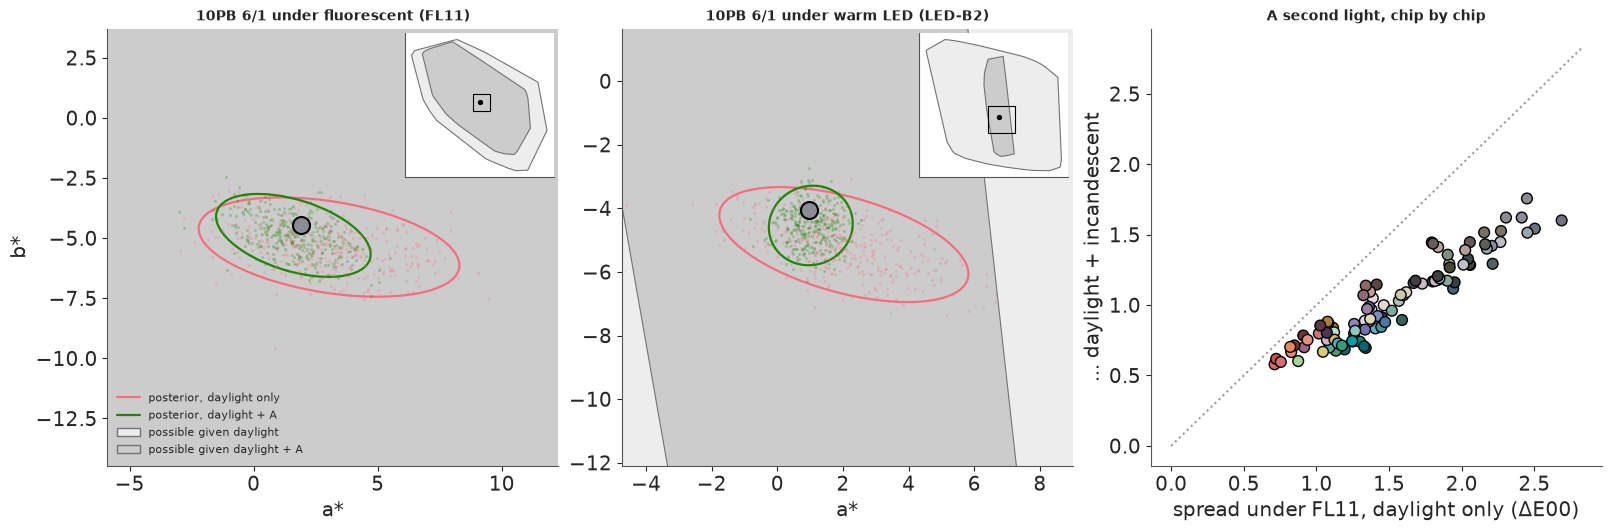

In [20]:
i = SHOW[0]
xi, xa = R_ALL[val[i]] @ W["D65"], R_ALL[val[i]] @ W["A"]
fig, axs = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, k in zip(axs[:2], ["FL11", "LED_B2"]):
    cloud_panel(ax, i, k, {"posterior, daylight only": (post[("learned", "D65")][:, i], "C1"),
                           "posterior, daylight + A": (post[("learned", "D65+A")][:, i], "C4")},
                [([xi], ("D65",), "0.93"), ([xi, xa], ("D65", "A"), "0.8")],
                zoom_from=post[("learned", "D65")][:, i])
axs[0].set_ylabel("b*")
h_, l_ = axs[0].get_legend_handles_labels()
axs[0].legend(h_ + [Patch(color="0.93", ec="0.45"), Patch(color="0.8", ec="0.45")],
              l_ + ["possible given daylight", "possible given daylight + A"], fontsize=8, loc="lower left")
ax = axs[2]
sp1, sp2 = spread(post[("learned", "D65")], "FL11"), spread(post[("learned", "D65+A")], "FL11")
ax.scatter(sp1, sp2, c=rgb(R_ALL[val]), s=60, edgecolor="k")
lim = max(sp1.max(), sp2.max()) * 1.05
ax.plot([0, lim], [0, lim], color="0.6", ls=":")
ax.set_xlabel("spread under FL11, daylight only (ΔE00)")
ax.set_ylabel("... daylight + incandescent")
ax.set_title("A second light, chip by chip", fontsize=10)
print(f"ratio of spreads under FL11 (two lights / one): median {np.median(sp2 / sp1):.2f}")

The second measurement shrinks the predicted FL11 spread by about a third (1.4 to 1.0 ΔE00, median)
and the LED spread by about half (1.1 to 0.6), while the coverage of the 90% intervals stays at
91-93%: the posterior gets sharper without getting overconfident. The LED gains most because the
warm LED and incandescent light have similar, smooth red-heavy spectra: measuring under one nearly
fixes the colour under the other. The physical bodies say the same thing (the darker grey region in
the inset of the LED panel is a thin sliver).
FL11's spiky spectrum probes combinations of wavelengths neither smooth light does, so some
uncertainty remains. A second light works on *every* chip (right panel: all points below the
diagonal), most for the grey, uncertain ones.

## G. A decision: matching a sample for a gallery

A gallery wants a wall to match a client's sample. The sample was measured with a colorimeter in
daylight (and, in a second version, under incandescent light too). The gallery is lit by a mix of
daylight and warm LEDs whose balance changes through the day: a share $w$ of daylight, with
$w \sim \text{Beta}(2, 2)$. The loss is the ΔE00 between wall and sample **under the gallery
light**, averaged over $w$. Two versions of the choice:

1. **Pick a chip.** Choose one of the 1,000 training chips (a "fan deck") for the wall. The naive rule
   takes the chip closest to the sample's daylight reading.
2. **Pick a recipe.** A supplier mixes a white base with three of eleven tints. Many recipes match the
   sample in daylight - metamers again, now among the *candidates* - and the naive rule takes the one
   with the **least pigment** (the cheapest). As a stand-in for a paint-formulation system: the tints
   are the most saturated training chip of each hue family plus a near-black, the base the lightest
   near-neutral chip, and mixtures follow single-constant **Kubelka-Munk** (as in E74, K/S is
   additive: $K/S_\text{mix} = \sum_j c_j\, K/S_j$ with fractions $c_j \ge 0$ summing to one). For
   each sample every one of the 165 three-tint recipes is fitted to the daylight reading
   (Levenberg-Marquardt on the fractions, all recipes at once), and those within ΔE00 0.5 are the
   candidates.

The **Bayes rule** picks the candidate with the smallest loss averaged over $w$ *and over the posterior
spectra of the sample*. The **oracle** knows the sample's true spectrum: the best anyone could do.
Every held-out chip plays the sample once, so every rule is scored on the truth.

In [21]:
def ks(R):
    return (1 - R) ** 2 / (2 * R)


def km(K):
    return 1 + K - np.sqrt(K**2 + 2 * K)


tr = mun.loc[train_idx]
TINTS = [int(tr[tr.hue_family == f].chroma.idxmax()) for f in ["R", "YR", "Y", "GY", "G", "BG", "B", "PB", "P", "RP"]]
TINTS.append(int(tr[tr.value == tr.value.min()].chroma.idxmin()))
WHITE = int(tr[tr.value == tr.value.max()].chroma.idxmin())
KW, KT = ks(R_ALL[WHITE]), ks(R_ALL[TINTS])
RECIPES = np.array(list(combinations(range(len(TINTS)), 3)))
print(f"white base {mun.chip[WHITE]}; tints {', '.join(mun.chip[TINTS])}; {len(RECIPES)} recipes")


def mix(u):
    """Recipes' reflectance from logits u (recipe x 3) of the three tints against the white base."""
    e = np.exp(np.concatenate([np.zeros((len(u), 1)), u], 1))
    c = e / e.sum(1, keepdims=True)
    return km(c[:, :1] * KW + np.einsum("rj,rjw->rw", c[:, 1:], KT[RECIPES])), c


def fit_recipes(y, iters=40):
    """Levenberg-Marquardt for all recipes at once: fractions whose daylight colour matches y."""
    u, lam = np.full((len(RECIPES), 3), -1.0), np.full(len(RECIPES), 1e-2)

    def resid(u_):
        return lab(mix(u_)[0]) - y
    r = resid(u)
    for _ in range(iters):
        J = np.stack([(resid(u + 1e-5 * np.eye(3)[k]) - r) / 1e-5 for k in range(3)], -1)
        step = np.linalg.solve(np.einsum("nij,nik->njk", J, J) + lam[:, None, None] * np.eye(3),
                               -np.einsum("nij,ni->nj", J, r)[..., None])[..., 0]
        un = np.clip(u + step, -12, 12)
        rn = resid(un)
        better = (rn**2).sum(1) < (r**2).sum(1)
        u, r = np.where(better[:, None], un, u), np.where(better[:, None], rn, r)
        lam = np.where(better, lam / 3, lam * 4)
    R, c = mix(u)
    return R, c, de2000(lab(R), y)


LED, D65s = light_spd("LED_B2"), light_spd("D65")
W_GRID = np.linspace(0, 1, 11)
W_PROB = beta_dist(2, 2).pdf(W_GRID)
W_PROB /= W_PROB.sum()
W_MIX = [observer(w * D65s / (D65s * CMF[:, 1]).sum() + (1 - w) * LED / (LED * CMF[:, 1]).sum()) for w in W_GRID]


def gallery_lab(R):
    return np.stack([lab(R, Wm) for Wm in W_MIX])              # w x ... x 3


def gallery_loss(lab_a, lab_b):
    """ΔE00 averaged over the daylight share w (axis 0)."""
    return np.tensordot(W_PROB, de2000(lab_a, lab_b), axes=(0, 0))


BAYES = {"Bayes, smooth GP": ("smooth GP", "D65"), "Bayes, learned": ("learned", "D65"),
         "Bayes, learned, daylight + A": ("learned", "D65+A")}


def decide(lab_cand, true_loss, ci):
    """True loss of the Bayes pick for each posterior; lab_cand is w x candidate x 3."""
    out = {}
    for label, key in BAYES.items():
        lab_post = gallery_lab(post[key][::4, ci])                  # w x draw x 3
        exp_loss = np.array([gallery_loss(lab_cand[:, r][:, None], lab_post).mean() for r in range(lab_cand.shape[1])])
        out[label] = true_loss[np.argmin(exp_loss)]
    return out


t0 = time.time()
train_gal = gallery_lab(R_ALL[train_idx])
chips_dec, recipe_dec = [], []
for ci in range(N_VAL):
    truth_gal = gallery_lab(R_ALL[val[ci]])[:, None]
    # 1. a chip from the fan deck: candidates are the 40 closest in daylight
    cand = np.argsort(de2000(LAB["D65"][train_idx], Y_OBS["D65"][ci]))[:40]
    tl = gallery_loss(train_gal[:, cand], truth_gal)
    chips_dec.append({"naive": tl[0], **decide(train_gal[:, cand], tl, ci), "oracle": tl.min()})
    # 2. a recipe
    Rrec, c, dE = fit_recipes(Y_OBS["D65"][ci])
    ok = np.flatnonzero(dE < 0.5)
    if len(ok) >= 2:
        lab_rec = gallery_lab(Rrec[ok])
        tl = gallery_loss(lab_rec, truth_gal)
        recipe_dec.append({"target": ci, "random daylight match": tl.mean(), "naive": tl[np.argmin(c[ok, 1:].sum(1))],
                           **decide(lab_rec, tl, ci), "oracle": tl.min()})
chips_dec, recipe_dec = pd.DataFrame(chips_dec), pd.DataFrame(recipe_dec)
print(f"{time.time() - t0:.0f} s; {len(recipe_dec)} of {N_VAL} samples can be matched by at least two recipes")
RULES = ["naive", *BAYES, "oracle"]
rows = {}
for name, d in [("pick a chip", chips_dec), ("pick a recipe", recipe_dec)]:
    diff = d[RULES].sub(d["naive"], axis=0)
    rows[(name, "mean ΔE00")] = d[RULES].mean()
    rows[(name, "vs naive")] = diff.mean()
    rows[(name, "± s.e.")] = diff.std() / np.sqrt(len(d))
    rows[(name, "share > 1")] = (d[RULES] > 1).mean()
dec_table = pd.DataFrame(rows).rename(index={"naive": "naive (nearest in daylight / least pigment)"})
print(dec_table.round(3))
print(f"recipes, a random daylight match: {recipe_dec['random daylight match'].mean():.2f}")

white base 5R 9/1; tints 5R 6/14, 2.5YR 6/14, 2.5Y 8/12, 2.5GY 8.5/10, 2.5G 6/12, 2.5BG 6/10, 10B 6/10, 5PB 4/12, 10P 5/12, 2.5RP 6/12, 5R 2.5/1; 165 recipes


7 s; 55 of 96 samples can be matched by at least two recipes
                                            pick a chip                           pick a recipe                          
                                              mean ΔE00 vs naive ± s.e. share > 1     mean ΔE00 vs naive ± s.e. share > 1
naive (nearest in daylight / least pigment)       2.233    0.000  0.000     0.927         0.801    0.000  0.000     0.255
Bayes, smooth GP                                  2.347    0.114  0.048     0.938         0.799   -0.002  0.030     0.236
Bayes, learned                                    2.299    0.066  0.034     0.938         0.787   -0.014  0.025     0.236
Bayes, learned, daylight + A                      2.166   -0.067  0.024     0.917         0.659   -0.142  0.028     0.109
oracle                                            2.142   -0.091  0.024     0.917         0.616   -0.185  0.029     0.091
recipes, a random daylight match: 0.89


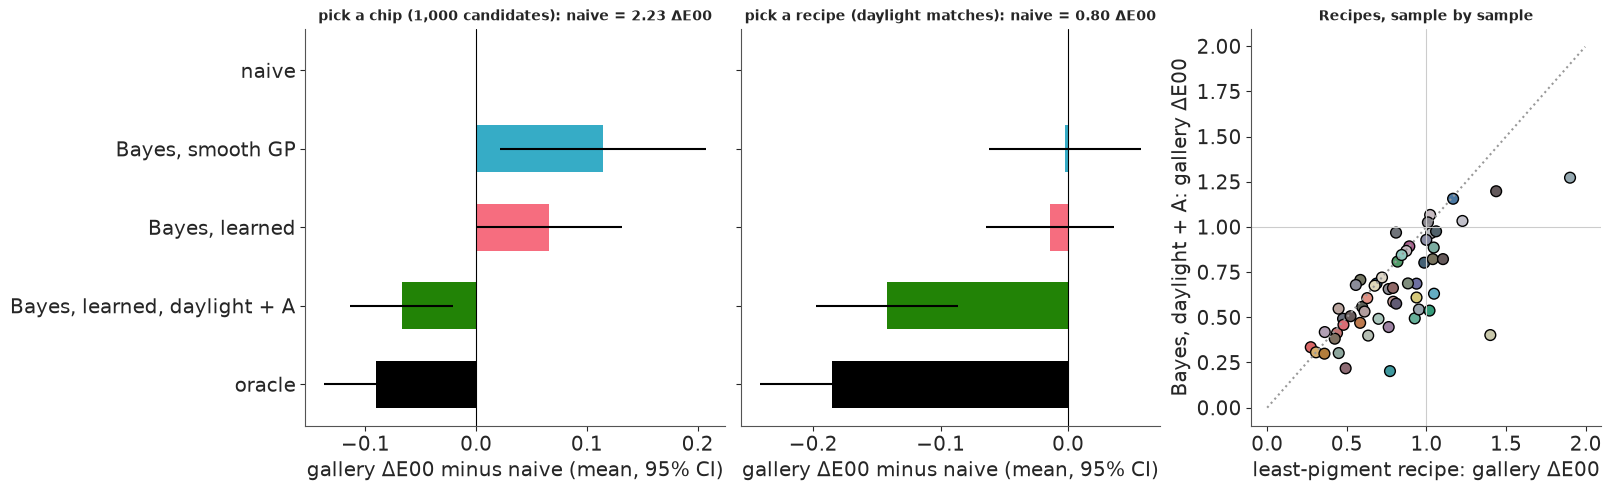

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.2, 1.2, 1]})
for ax, (name, d) in zip(axs[:2], [("pick a chip (1,000 candidates)", chips_dec), ("pick a recipe (daylight matches)", recipe_dec)]):
    diff = d[RULES].sub(d["naive"], axis=0)
    m, se = diff.mean(), diff.std() / np.sqrt(len(d))
    cols = ["0.5", "C0", "C1", "C4", "k"]
    ax.barh(range(len(RULES)), m.values, xerr=1.96 * se.values, color=cols, height=0.6)
    ax.set_yticks(range(len(RULES)))
    ax.set_yticklabels(["naive", *BAYES, "oracle"] if ax is axs[0] else [""] * len(RULES))
    ax.axvline(0, color="k", lw=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("gallery ΔE00 minus naive (mean, 95% CI)")
    ax.set_title(f"{name}: naive = {d['naive'].mean():.2f} ΔE00", fontsize=10)
ax = axs[2]
tg = recipe_dec.target.to_numpy()
ax.scatter(recipe_dec["naive"], recipe_dec["Bayes, learned, daylight + A"], c=rgb(R_ALL[val[tg]]), s=60, edgecolor="k")
lim = recipe_dec[["naive", "Bayes, learned, daylight + A"]].to_numpy().max() * 1.05
ax.plot([0, lim], [0, lim], color="0.6", ls=":")
ax.axhline(1, color="0.8", lw=0.8)
ax.axvline(1, color="0.8", lw=0.8)
ax.set_xlabel("least-pigment recipe: gallery ΔE00")
ax.set_ylabel("Bayes, daylight + A: gallery ΔE00")
ax.set_title("Recipes, sample by sample", fontsize=10);

Reading the table and the figure:

* **Picking a recipe.** A random daylight match leaves the wall 0.89 ΔE00 from the sample in the
  gallery, the least-pigment rule 0.80, and the oracle 0.62. With one daylight reading the Bayes rule
  is no better than least pigment (the difference, -0.01 ± 0.03, is noise), whichever prior it uses.
  With a **second reading under incandescent light** it closes about three-quarters of the gap to the
  oracle (0.66 ΔE00) and cuts the share of walls with a visible mismatch (> 1 ΔE00) from about a
  quarter to 11%, close to the oracle's 9%.
* **Picking a chip.** The fan deck is coarse (even the oracle's pick is 2.1 ΔE00 from the sample on
  average), so nearly every pick is visibly off whatever the rule, and the oracle beats the naive
  rule by only 0.09 ΔE00.
  Here the one-light Bayes rules are *worse* than naive, by 0.07 ± 0.03 (learned) and 0.11 ± 0.05
  (GP). Two lights again beat the naive rule, by 0.07, most of what the oracle gains.

So a calibrated posterior did not, by itself, make a better decision than a simple rule. Why did the
naive chip rule win? Taking the chip nearest in daylight quietly uses a second prior: the target's
*neighbours* in the Munsell set, whose spectra (similar pigments, similar colour) shift with the light
much as the target's does. The learned prior is one Gaussian for the whole set and knows nothing
local. A direct check: predict each sample's colour under the other lights as its daylight reading
plus the colour shift of its nearest training chip, and compare with the posterior median.

In [23]:
nb_rows = []
for k in ["A", "FL11", "LED_B2"]:
    e_nb, e_post = [], []
    for ci in range(N_VAL):
        nn = train_idx[np.argmin(de2000(LAB["D65"][train_idx], Y_OBS["D65"][ci]))]
        e_nb.append(de2000(Y_OBS["D65"][ci] + LAB[k][nn] - LAB["D65"][nn], TRUE[k][ci]))
        e_post.append(de2000(np.median(lab(post[("learned", "D65")][:, ci], k), 0), TRUE[k][ci]))
    nb_rows.append((LIGHT_NAMES[k], np.median(e_nb), np.median(e_post)))
print(pd.DataFrame(nb_rows, columns=["light", "nearest chip's shift", "posterior median (learned)"])
      .set_index("light").round(2).rename_axis("median ΔE00 error of the predicted colour"))

                                           nearest chip's shift  posterior median (learned)
median ΔE00 error of the predicted colour                                                  
incandescent (A)                                           0.91                        0.98
fluorescent (FL11)                                         0.89                        1.17
warm LED (LED-B2)                                          0.93                        1.05


The nearest chip's colour shift predicts the colour under the other lights *better* than the learned
posterior does, most clearly under FL11. The learned prior is calibrated but not the sharpest prior
these data support: the Munsell spectra lie on a curved, lumpy set (a hue circle at every lightness),
and a single Gaussian fills in the gaps between the lumps. That is the next model to build (see "Try
it yourself"). Calibration is necessary for good decisions, not sufficient; and here the most
valuable thing the posterior did was tell us that **a second measurement** was worth taking.

## H. Walking through the metamers

An animation for the bluish grey chip of Part D. The top row walks through **physically possible**
metamers (points halfway between the chip and linear-programming extremes, which are exact metamers
too, since the colour is linear in the spectrum); the bottom row through **plausible** ones,
posterior draws under the learned prior. Left: the spectrum (drawn in its daylight colour) against
the chip's own (dashed). Right: a swatch under daylight and under FL11, with the real chip as the
inner rectangle of each half.

In [24]:
i = SHOW[0]
Rt = R_ALL[val[i]]
xt = Rt @ W["D65"]
FLW = W["FL11"]
ext = [lp_metamer([xt], -(FLW @ np.array([np.cos(a), np.sin(a), -0.5 * (np.cos(a) + np.sin(a))])))
       for a in np.linspace(0, 2 * np.pi, 7)[:-1]]
Rd = post[("learned", "D65")][:, i]
LA = lab(Rd, "FL11")
hue = np.arctan2(LA[:, 2] - LA[:, 2].mean(), LA[:, 1] - LA[:, 1].mean())
plaus = [Rd[np.argmin(np.abs(hue - h))] for h in np.linspace(-np.pi, np.pi, 7)[:-1]]


def walk(keys, steps=7):
    keys = keys + keys[:1]
    return np.concatenate([np.linspace(0, 1, steps, endpoint=False)[:, None] * (b - a)[None] + a[None]
                           for a, b in zip(keys[:-1], keys[1:])])


paths = [walk([0.5 * e + 0.5 * Rt for e in ext]), walk(plaus)]
print(f"{len(paths[0])} frames; largest daylight ΔE00 from the chip along each path: "
      f"{[round(float(de2000(lab(p), lab(Rt)).max()), 2) for p in paths]}")

fig, axs = plt.subplots(2, 2, figsize=(8.4, 5.4), dpi=72, gridspec_kw={"width_ratios": [1.7, 1]}, layout="none")
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.1, top=0.9, wspace=0.12, hspace=0.45)
arts = []
for r_, (p, name) in enumerate(zip(paths, ["physically possible metamers", "plausible metamers (learned prior)"])):
    ax = axs[r_, 0]
    ax.plot(WL, Rt, color="k", lw=1, ls="--")
    line, = ax.plot(WL, p[0], lw=2.5, color=rgb(p[0]))
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)
    ax = axs[r_, 1]
    ax.axis("off")
    im = ax.imshow(np.zeros((10, 20, 3)))
    ax.text(5, -1.2, "daylight", ha="center", fontsize=8)
    ax.text(15, -1.2, "FL11", ha="center", fontsize=8)
    txt = ax.text(10, 11.8, "", ha="center", fontsize=8)
    arts.append((line, im, txt))
axs[1, 0].set_xlabel("wavelength (nm)", fontsize=8)


def swatch_img(Rm):
    img = np.zeros((10, 20, 3))
    for c_, k in enumerate(["D65", "FL11"]):
        img[:, 10 * c_:10 * c_ + 10] = rgb(Rm, k)
        img[2:8, 10 * c_ + 5:10 * c_ + 9] = rgb(Rt, k)
    return img


def update(f):
    out = []
    for (line, im, txt), p in zip(arts, paths):
        line.set_ydata(p[f])
        line.set_color(rgb(p[f]))
        im.set_data(swatch_img(p[f]))
        txt.set_text(f"FL11: ΔE00 {de2000(lab(p[f], 'FL11'), lab(Rt, 'FL11')):.1f} from the chip")
        out += [line, im, txt]
    return out


anim = animation.FuncAnimation(fig, update, frames=len(paths[0]), interval=180)
plt.close(fig)
plt.rcParams["animation.frame_format"] = "jpeg"          # swatches: JPEG frames are far smaller
display(HTML(anim.to_jshtml(default_mode="loop")))
plt.rcParams["animation.frame_format"] = "png"

42 frames; largest daylight ΔE00 from the chip along each path: [0.0, 1.5]


Along the top path the spectrum jumps between blocks and the daylight half of the swatch never
changes, while the FL11 half swings through strongly coloured yellow-greens, greens and purples, 20-28
ΔE00 from the chip. Along the bottom path the spectrum barely moves below 650 nm, and the FL11 half
shifts by 1.5-4 ΔE00 around the chip. Both rows are "the same colour"; only one of them is what
real surfaces do. (The plausible path is built from posterior draws, which match the *noisy*
reading, so its daylight colour wanders by up to 1.5 ΔE00; the physical path is exact.)

## Summary

* **A colour is a projection.** Under one light the observer is a 3 x 41 matrix; the 38 directions it
  cannot see (metameric blacks) can be added to any surface without changing its colour. Linear
  programming gives the exact set of colours those metamers can have under another light: tens of
  ΔE00 wide. Real surfaces use a tiny part of it: near-metameric Munsell pairs stay within 1-3.
* **The prior does the work.** A smoothness-only GP leaves a vague metamer set (3-5 ΔE00 under the
  other lights); with a covariance learned from 1,000 measured surfaces, one daylight colour removes
  96% of the prior variance, the colour under incandescent, fluorescent and LED light is predicted
  to about 1 ΔE00, and the predictions are calibrated on held-out chips. The textbook 3-component
  linear model gives about the same best guess but claims about half the spread it should (its 90%
  intervals cover 66-74%).
* **Batch small independent inversions into one model** (a `chip` dimension): one compilation, one
  sampler run, 96 posteriors. Expect deep trees: 3 of 41 directions are pinned by data.
* **Validate predictions, not parameters**: coverage of spectral bands, and above all the PIT and
  interval coverage of the colour under lights that were *not* measured. Confidence follows chroma
  (saturated colours have few metamers); honesty follows typicality (unusual spectra are the misses).
* **Information beats cleverness.** One more reading under a second light shrinks the predicted
  spread by a third to a half and makes the Bayes decision clearly better than simple rules; with one
  reading, a naive nearest-chip rule did as well or better, because it silently used a *local* prior
  the global Gaussian lacks.
* **When colour is the uncertainty, show colour**: spaghetti of spectra drawn in their rendered
  colours, swatch fans, split swatches and the animation make metamer mismatch visible directly;
  a*b* clouds against the physical body and calibration plots make it quantitative.

## Try it yourself

1. **A local prior.** Replace the single Gaussian by a mixture: k-means (or the hue families) on the
   training logit-spectra, one mean and covariance per cluster, and the cluster summed out inside the
   model with `pt.logsumexp` (or a kernel prior centred on every training spectrum). Does the
   posterior get sharper under FL11 while the 90% coverage stays near 90%? Does the one-light Bayes
   rule now beat the nearest-chip rule of Part G?
2. **Which second light?** Repeat Part F with the second reading under FL11 or LED-B2 instead of A
   (and try FL2 and LED-B4 from `cie_illuminants_e76`). Which single extra light best predicts the
   others? Before measuring anything, the closed-form linear-Gaussian calculation of Part C ranks the
   candidates: does its ranking agree with the full posterior?
3. **A camera as the observer.** Replace the second light by a second *observer*: a camera's three
   spectral sensitivities (published measurements exist for dozens of camera models) under daylight.
   How much does one photograph shrink the metamer set compared with a colorimeter under a second
   light, and where in the spectrum does the camera see what the eye does not?